# Complete Dissertation NLP Analysis

**Project:** NLP-based benchmarking of corporate risk disclosures in FTSE 100 annual reports  
**Sample:** 9 companies × 3 years (2023–2025) = 27 full annual reports

This notebook creates reproducible outputs for Chapter 4:

1. Project Setup

2. Data Loading

3. Text Cleaning

4. Keyword Frequency Analysis

5. Word Cloud

6. TF-IDF Analysis

7. Topic Modelling

8. Sentiment Analysis

9. Readability Analysis

10. Statistical Analysis
    • Descriptive Statistics
    • Shapiro–Wilk
    • Levene
    • ANOVA
    • Kruskal–Wallis

11. Correlation Analysis

12. Trend Analysis

13. Enhanced Risk Disclosure Quality Index (RDQI)

14. Enhanced RDQI Sensitivity Analysis

15. Executive Consultancy Dashboard

16. Final Output Checklist


In [47]:
from pathlib import Path

PROJECT_PATH = Path(r"C:\Users\HP\OneDrive\Desktop\Dissertation_project")

SOURCE_MODE = "full_reports"   

if SOURCE_MODE == "risk_sections":
    INPUT_PATH = PROJECT_PATH / "output" / "risk_sections"
else:
    INPUT_PATH = PROJECT_PATH / "output" / "extracted_text"

OUTPUT_PATH = PROJECT_PATH / "output"
TABLES_PATH = OUTPUT_PATH / "tables"
FIGURES_PATH = OUTPUT_PATH / "figures"
MODELS_PATH = OUTPUT_PATH / "models"
CLEANED_PATH = OUTPUT_PATH / "cleaned_text"

for folder in [TABLES_PATH, FIGURES_PATH, MODELS_PATH, CLEANED_PATH]:
    folder.mkdir(parents=True, exist_ok=True)

print("Input path:", INPUT_PATH)
print("Source mode:", SOURCE_MODE)
print("Input folder exists:", INPUT_PATH.exists())

Input path: C:\Users\HP\OneDrive\Desktop\Dissertation_project\output\extracted_text
Source mode: full_reports
Input folder exists: True


## 2. Installing required packages

Running this cell only if packages are missing.

In [48]:

import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn nltk wordcloud joblib

Defaulting to user installation because normal site-packages is not writeable


## Additional packages for the enhanced analysis
Running the next cell only if packages are missing.

In [49]:
import sys
!{sys.executable} -m pip install textstat scipy wordcloud

Defaulting to user installation because normal site-packages is not writeable


In [50]:
import nltk

resources = [
    "stopwords",
    "wordnet",
    "omw-1.4",
    "punkt",
    "punkt_tab",
    "vader_lexicon"
]

for resource in resources:
    nltk.download(resource)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## 3. Import and reproducibility settings

In [51]:
import re
import math
import string
import platform
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.preprocessing import MinMaxScaler
from scipy import stats

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tokenize import sent_tokenize

import joblib
import textstat
from wordcloud import WordCloud

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

for resource in ["stopwords", "wordnet", "omw-1.4", "punkt", "punkt_tab", "vader_lexicon"]:
    nltk.download(resource, quiet=True)

print("Python:", platform.python_version())
print("Pandas:", pd.__version__)

Python: 3.13.5
Pandas: 2.2.3


## 4. Company and sector metadata

In [52]:
SECTOR_MAP = {
    "HSBC": "Banking",
    "BARCLAYS": "Banking",
    "LLOYDS": "Banking",
    "BP": "Energy",
    "SHELL": "Energy",
    "SSE": "Energy",
    "TESCO": "Retail",
    "MARKS & SPENCER": "Retail",
    "NEXT": "Retail",
}

COMPANY_PATTERNS = {
    "HSBC": r"\bHSBC\b",
    "Barclays": r"\bBARCLAYS\b",
    "Lloyds Banking Group": r"\bLLOYDS\b",
    "BP": r"\bBP\b",
    "Shell": r"\bSHELL\b",
    "SSE": r"\bSSE\b",
    "Tesco": r"\bTESCO\b",
    "Marks & Spencer": r"\bMARKS\s*&\s*SPENCER\b|\bM-and-S\b",
    "Next": r"\bNEXT\b",
}

def infer_year(file_name: str):
    """
    Infer the reporting year from filenames containing:
    2023, 2024, 2025, ar23, ar24, ar25,
    or similar shortened filename formats.
    """
    file_name = str(file_name).lower()

    # Full four-digit year
    full_year = re.findall(r"(2023|2024|2025)", file_name)

    if full_year:
        return int(full_year[-1])

    # Shortened forms used in filenames
    if re.search(r"ar[_-]?23", file_name):
        return 2023

    if re.search(r"ar[_-]?24", file_name):
        return 2024

    if re.search(r"ar[_-]?25", file_name):
        return 2025

    return np.nan

## 5. Load and validate the corpus

In [53]:
text_files = sorted(INPUT_PATH.glob("*.txt"))

In [54]:
import re
import numpy as np


COMPANY_PATTERNS = {
    "HSBC": r"\bHSBC\b",
    "Barclays": r"\bBARCLAYS\b",
    "Lloyds Banking Group": r"\bLLOYDS\b",
    "BP": r"\bBP\b",
    "Shell": r"\bSHELL\b",
    "SSE": r"\bSSE\b",
    "Tesco": r"\bTESCO\b",
    "Marks & Spencer": r"\bMARKS\s*&\s*SPENCER\b|\bM-AND-S\b",
    "Next": r"\bNEXT\b",
}


def infer_company(file_name: str) -> str:
    """
    Infer company name from the report filename.
    """
    file_name_upper = str(file_name).upper()

    for company, pattern in COMPANY_PATTERNS.items():
        if re.search(pattern, file_name_upper, flags=re.IGNORECASE):
            return company

    return "Unknown"


def infer_sector(company: str) -> str:
    """
    Map each company to its sector.
    """
    sector_map = {
        "HSBC": "Banking",
        "Barclays": "Banking",
        "Lloyds Banking Group": "Banking",
        "BP": "Energy",
        "Shell": "Energy",
        "SSE": "Energy",
        "Tesco": "Retail",
        "Marks & Spencer": "Retail",
        "Next": "Retail",
    }

    return sector_map.get(company, "Unknown")


def infer_year(file_name: str):
    """
    Infer reporting year from filenames containing full years
    or shortened forms such as ar24 and ar25.
    """
    file_name_lower = str(file_name).lower()

    full_year = re.findall(r"(2023|2024|2025)", file_name_lower)

    if full_year:
        return int(full_year[-1])

    if re.search(r"ar[_-]?23", file_name_lower):
        return 2023

    if re.search(r"ar[_-]?24", file_name_lower):
        return 2024

    if re.search(r"ar[_-]?25", file_name_lower):
        return 2025

    return np.nan


print("Metadata functions loaded successfully.")

Metadata functions loaded successfully.


## 6. Preprocess text

The cleaning pipeline removes formatting artefacts while retaining meaningful risk terminology.

In [55]:
text_files = sorted(INPUT_PATH.glob("*.txt"))

records = []

for file in text_files:
    raw_text = file.read_text(
        encoding="utf-8",
        errors="ignore"
    )

    company = infer_company(file.name)
    year = infer_year(file.name)
    sector = infer_sector(company)

    records.append({
        "file_name": file.name,
        "company": company,
        "sector": sector,
        "year": year,
        "raw_text": raw_text,
        "raw_word_count": len(raw_text.split()),
        "character_count": len(raw_text),
    })

docs = pd.DataFrame(records)

print("Documents loaded:", len(docs))
print("Missing years:", docs["year"].isna().sum())
print("Shape:", docs.shape)

display(
    docs[
        [
            "file_name",
            "company",
            "sector",
            "year",
            "raw_word_count"
        ]
    ]
)

Documents loaded: 27
Missing years: 0
Shape: (27, 7)


,file_name,company,sector,year,raw_word_count
0,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2023,322847
1,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2024,348662
2,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2025,318609
3,BP ANNUAL REPORTS_bp-annual-report-and-form-20...,BP,Energy,2023,271770
4,BP ANNUAL REPORTS_bp-annual-report-and-form-20...,BP,Energy,2024,258244
5,BP ANNUAL REPORTS_bp-annual-report-and-form-20...,BP,Energy,2025,267369
6,HSBC ANNUAL REPORT_240226-annual-report-and-ac...,HSBC,Banking,2023,343861
7,HSBC ANNUAL REPORT_250219-annual-report-and-ac...,HSBC,Banking,2024,349227
8,HSBC ANNUAL REPORT_260225-annual-report-and-ac...,HSBC,Banking,2025,292682
9,LLOYDS ANNUAL REPORT_2023-lbg-annual-report.txt,Lloyds Banking Group,Banking,2023,243608


## 7. Dataset overview figure

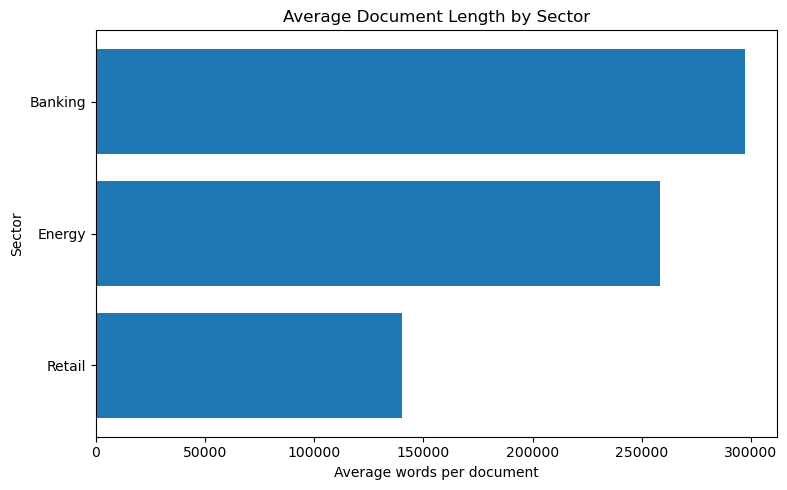

In [56]:
dataset_overview = (
    docs.groupby(["sector", "year"], as_index=False)
    .agg(
        reports=("file_name", "count"),
        average_words=("raw_word_count", "mean")
    )
)

dataset_overview.to_csv(
    TABLES_PATH / f"{SOURCE_MODE}_dataset_overview.csv",
    index=False,
    encoding="utf-8-sig"
)

sector_word_counts = (
    docs.groupby("sector")["raw_word_count"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))
plt.barh(sector_word_counts.index, sector_word_counts.values)
plt.xlabel("Average words per document")
plt.ylabel("Sector")
plt.title("Average Document Length by Sector")
plt.tight_layout()
plt.savefig(
    FIGURES_PATH / f"{SOURCE_MODE}_average_document_length_by_sector.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# 8. Keyword frequency analysis

In [57]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOP_WORDS = set(stopwords.words("english"))

CUSTOM_STOP_WORDS = {
    "page", "annual", "report", "reports", "account", "accounts",
    "statement", "statements", "section", "appendix",
    "table", "figure", "note", "notes", "continued", "review",

    
    "plc", "group", "company", "companies", "limited", "ltd",
    "corporation", "holding", "holdings", "subsidiary",

    
    "barclays", "hsbc", "lloyds", "lloyd", "shell",
    "tesco", "next", "marks", "spencer", "mands", "sse", "bp",

    
    "venkatakrishnan", "anna", "stuart", "wolfson", "charlie",

    
    "year", "million", "billion", "financial",
    "information", "also", "may", "could", "would",
    "one", "two", "three",

    
    "income", "cash", "total", "net", "share", "shares",
    "asset", "assets", "liability", "liabilities",

   
    "home", "resource", "hub", "interactive",

    
    "including", "include", "included",
    "provide", "provided", "provides",
    "using", "used", "within", "across"
}

STOP_WORDS.update(CUSTOM_STOP_WORDS)

LEMMATIZER = WordNetLemmatizer()


def clean_text(text: str) -> str:
    text = text.lower()

    text = re.sub(
        r"---\s*page\s+\d+\s*---",
        " ",
        text,
        flags=re.IGNORECASE
    )

    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^a-z\s-]", " ", text)
    text = re.sub(r"\b[a-z]\b", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = []

    for token in text.split():
        token = token.strip("-")

        if (
            len(token) >= 3
            and token not in STOP_WORDS
            and not token.isnumeric()
        ):
            lemma = LEMMATIZER.lemmatize(token)
            tokens.append(lemma)

    return " ".join(tokens)


docs["clean_text"] = docs["raw_text"].apply(clean_text)

docs["clean_word_count"] = (
    docs["clean_text"]
    .str.split()
    .str.len()
)

docs["vocabulary_size"] = (
    docs["clean_text"]
    .str.split()
    .apply(lambda words: len(set(words)))
)

docs["lexical_diversity"] = (
    docs["vocabulary_size"]
    / docs["clean_word_count"].replace(0, np.nan)
)

print("Cleaning completed.")
print(docs[["file_name", "clean_word_count"]].head())
print("Columns now:", docs.columns.tolist())

Cleaning completed.
                                           file_name  clean_word_count
0  BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...            153773
1  BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...            165197
2  BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...            150447
3  BP ANNUAL REPORTS_bp-annual-report-and-form-20...            129539
4  BP ANNUAL REPORTS_bp-annual-report-and-form-20...            122929
Columns now: ['file_name', 'company', 'sector', 'year', 'raw_text', 'raw_word_count', 'character_count', 'clean_text', 'clean_word_count', 'vocabulary_size', 'lexical_diversity']


## 8.1 Top keywords by sector

In [58]:
sector_keyword_rows = []

for sector, group in docs.groupby("sector"):
    counts = Counter(" ".join(group["clean_text"]).split())
    for rank, (keyword, frequency) in enumerate(counts.most_common(20), start=1):
        sector_keyword_rows.append({
            "sector": sector,
            "rank": rank,
            "keyword": keyword,
            "frequency": frequency
        })

sector_keywords = pd.DataFrame(sector_keyword_rows)
sector_keywords.to_csv(
    TABLES_PATH / f"{SOURCE_MODE}_top_keywords_by_sector.csv",
    index=False,
    encoding="utf-8-sig"
)

display(sector_keywords.head(30))

,sector,rank,keyword,frequency
0,Banking,1,risk,26119
1,Banking,2,business,7902
2,Banking,3,management,7734
3,Banking,4,committee,7689
4,Banking,5,value,7348
5,Banking,6,board,6803
6,Banking,7,customer,6770
7,Banking,8,bank,6679
8,Banking,9,credit,6549
9,Banking,10,climate,6109


# 9. TF-IDF analysis

TF-IDF highlights terms that are distinctive within reports rather than merely frequent across the whole corpus.

In [59]:
TFIDF_MAX_FEATURES = 1000

tfidf_vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True
)

tfidf_matrix = tfidf_vectorizer.fit_transform(docs["clean_text"])
tfidf_terms = tfidf_vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_terms,
    index=docs["file_name"]
)

top_tfidf_rows = []
for file_name in tfidf_df.index:
    top_terms = tfidf_df.loc[file_name].sort_values(ascending=False).head(20)
    metadata = docs.loc[docs["file_name"] == file_name].iloc[0]

    for rank, (term, score) in enumerate(top_terms.items(), start=1):
        top_tfidf_rows.append({
            "file_name": file_name,
            "company": metadata["company"],
            "sector": metadata["sector"],
            "year": metadata["year"],
            "rank": rank,
            "term": term,
            "tfidf_score": score
        })

top_tfidf = pd.DataFrame(top_tfidf_rows)
top_tfidf.to_csv(
    TABLES_PATH / f"{SOURCE_MODE}_top_tfidf_terms_by_report.csv",
    index=False,
    encoding="utf-8-sig"
)

display(top_tfidf.head(25))

,file_name,company,sector,year,rank,term,tfidf_score
0,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2023,1,shareholder climate,0.132654
1,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2023,2,strategic shareholder,0.116261
2,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2023,3,corporate loan,0.109533
3,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2023,4,ukrf,0.107921
4,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2023,5,implementing climate,0.103356
5,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2023,6,strong strong,0.094355
6,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2023,7,strategy recommendation,0.092000
7,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2023,8,retail corporate,0.090862
8,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2023,9,advance amortised,0.088726
9,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2023,10,card retail,0.085998


## 9.1 TF-IDF heatmap

The heatmap uses the top 20 terms by average TF-IDF score.

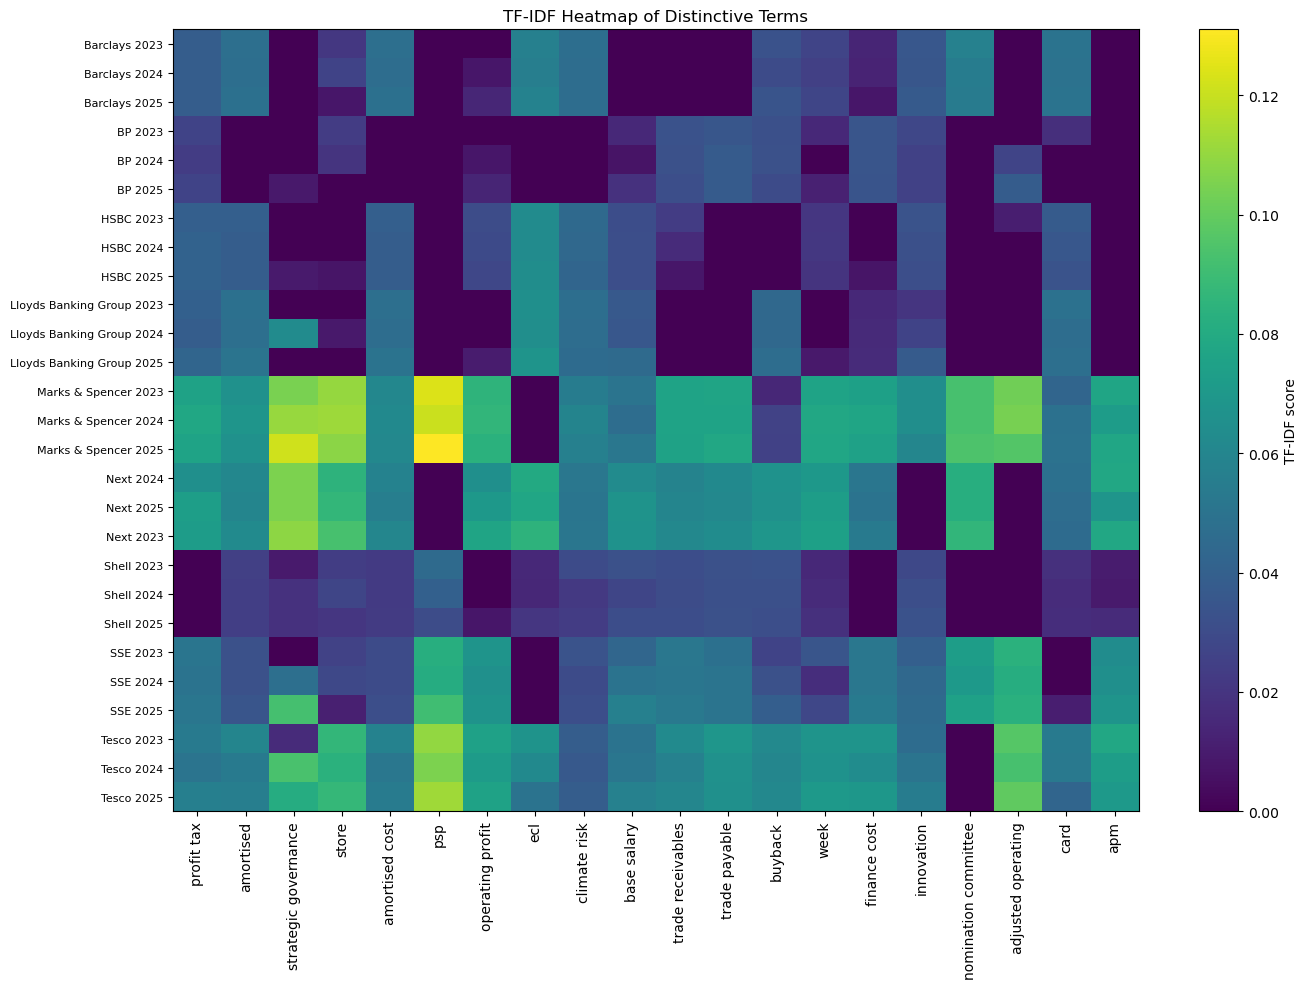

In [60]:
top_heatmap_terms = (
    tfidf_df.mean(axis=0)
    .sort_values(ascending=False)
    .head(20)
    .index
)

heatmap = tfidf_df.loc[:, top_heatmap_terms].copy()

metadata_for_heatmap = (
    docs.set_index("file_name")
    .reindex(heatmap.index)
)

def create_report_label(row):
    company = row["company"] if pd.notna(row["company"]) else "Unknown company"
    year_label = str(int(row["year"])) if pd.notna(row["year"]) else "Year unknown"
    return f"{company} {year_label}"

heatmap.index = metadata_for_heatmap.apply(
    create_report_label,
    axis=1
)

plt.figure(figsize=(14, 10))
image = plt.imshow(heatmap.values, aspect="auto")
plt.colorbar(image, label="TF-IDF score")
plt.xticks(
    range(len(heatmap.columns)),
    heatmap.columns,
    rotation=90
)
plt.yticks(
    range(len(heatmap.index)),
    heatmap.index,
    fontsize=8
)
plt.title("TF-IDF Heatmap of Distinctive Terms")
plt.tight_layout()
plt.savefig(
    FIGURES_PATH / f"{SOURCE_MODE}_tfidf_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# 10. Topic modelling

The notebook compares several topic counts and reports model perplexity. Final topic selection should also consider interpretability.

In [61]:
TOPIC_MIN = 4
TOPIC_MAX = 8
TOP_WORDS = 12

count_vectorizer = CountVectorizer(
    max_features=1500,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.90
)

count_matrix = count_vectorizer.fit_transform(docs["clean_text"])
count_terms = count_vectorizer.get_feature_names_out()

topic_diagnostics = []

for n_topics in range(TOPIC_MIN, TOPIC_MAX + 1):
    model = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=RANDOM_STATE,
        learning_method="batch",
        max_iter=30
    )
    model.fit(count_matrix)

    topic_diagnostics.append({
        "n_topics": n_topics,
        "perplexity": model.perplexity(count_matrix),
        "log_likelihood": model.score(count_matrix)
    })

topic_diagnostics = pd.DataFrame(topic_diagnostics)
topic_diagnostics.to_csv(
    TABLES_PATH / f"{SOURCE_MODE}_topic_model_diagnostics.csv",
    index=False,
    encoding="utf-8-sig"
)

display(topic_diagnostics)

,n_topics,perplexity,log_likelihood
0,4,662.716478,-2.671655e+06
1,5,654.356272,-2.666434e+06
2,6,610.811650,-2.638114e+06
3,7,527.061259,-2.577465e+06
4,8,498.848553,-2.554840e+06


## 10.1 Fit the final topic model



In [62]:
FINAL_N_TOPICS = 6

lda_model = LatentDirichletAllocation(
    n_components=FINAL_N_TOPICS,
    random_state=RANDOM_STATE,
    learning_method="batch",
    max_iter=50
)

document_topic_matrix = lda_model.fit_transform(count_matrix)

topic_rows = []
for topic_number, weights in enumerate(lda_model.components_, start=1):
    top_indices = weights.argsort()[::-1][:TOP_WORDS]
    top_terms = [count_terms[index] for index in top_indices]

    topic_rows.append({
        "topic": topic_number,
        "top_terms": ", ".join(top_terms)
    })

topic_terms = pd.DataFrame(topic_rows)
topic_terms.to_csv(
    TABLES_PATH / f"{SOURCE_MODE}_lda_topic_terms.csv",
    index=False,
    encoding="utf-8-sig"
)

display(topic_terms)

,topic,top_terms
0,1,"cost ratio, contractual maturity, esg data, op..."
1,2,"store, strategic governance, operating profit,..."
2,3,"membership interest, llc, llc membership, adju..."
3,4,"llc, chemical, energy transition, oil gas, lng..."
4,5,"ecl, loan advance, cent, per cent, lending, wi..."
5,6,"client, climate sustainability, strategic shar..."


## 10.2 Document and sector topic prevalence

In [63]:
topic_columns = [f"topic_{i}" for i in range(1, FINAL_N_TOPICS + 1)]

document_topics = pd.DataFrame(
    document_topic_matrix,
    columns=topic_columns
)

document_topics = pd.concat(
    [
        docs[["file_name", "company", "sector", "year"]].reset_index(drop=True),
        document_topics
    ],
    axis=1
)

document_topics["dominant_topic"] = (
    document_topics[topic_columns].idxmax(axis=1)
)

document_topics.to_csv(
    TABLES_PATH / f"{SOURCE_MODE}_document_topic_distribution.csv",
    index=False,
    encoding="utf-8-sig"
)

sector_topics = (
    document_topics.groupby("sector")[topic_columns]
    .mean()
)

sector_topics.to_csv(
    TABLES_PATH / f"{SOURCE_MODE}_sector_topic_prevalence.csv",
    encoding="utf-8-sig"
)

display(document_topics.head())
display(sector_topics)

,file_name,company,sector,year,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,dominant_topic
0,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2023,0.000007,0.000007,0.000007,0.000007,0.000007,0.999963,topic_6
1,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2024,0.000007,0.000007,0.000007,0.000007,0.000007,0.999966,topic_6
2,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2025,0.000007,0.000007,0.000007,0.000007,0.000007,0.999964,topic_6
3,BP ANNUAL REPORTS_bp-annual-report-and-form-20...,BP,Energy,2023,0.000008,0.000008,0.979072,0.020896,0.000008,0.000008,topic_3
4,BP ANNUAL REPORTS_bp-annual-report-and-form-20...,BP,Energy,2024,0.000008,0.000008,0.982556,0.017411,0.000008,0.000008,topic_3


,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6
sector,,,,,,
Banking,0.000008,0.000337,0.000008,0.000008,0.644219,0.355419
Energy,0.000010,0.044732,0.368343,0.356489,0.230415,0.000010
Retail,0.000028,0.674164,0.277743,0.000455,0.044128,0.003481


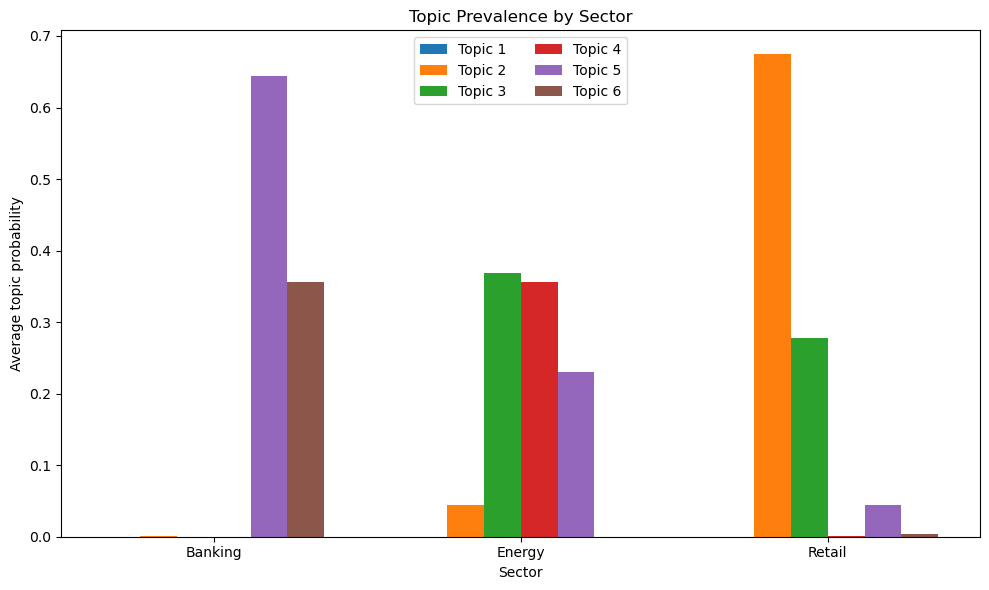

In [64]:
plt.figure(figsize=(10, 6))

x = np.arange(len(sector_topics.index))
width = 0.12

for i, topic in enumerate(topic_columns):
    plt.bar(
        x + (i - (len(topic_columns)-1)/2) * width,
        sector_topics[topic].values,
        width,
        label=topic.replace("_", " ").title()
    )

plt.xticks(x, sector_topics.index)
plt.ylabel("Average topic probability")
plt.xlabel("Sector")
plt.title("Topic Prevalence by Sector")
plt.legend(ncol=2)
plt.tight_layout()
plt.savefig(
    FIGURES_PATH / f"{SOURCE_MODE}_topic_prevalence_by_sector.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# 11. Sentiment analysis

VADER is applied to sentence-level raw text. It is transparent and reproducible, but it is not finance-specific; this limitation must be acknowledged.

In [65]:
sia = SentimentIntensityAnalyzer()

def analyse_sentiment(text: str) -> dict:
    sentences = sent_tokenize(text)

    # Remove extremely short fragments
    sentences = [
        sentence.strip()
        for sentence in sentences
        if len(sentence.split()) >= 5
    ]

    if not sentences:
        return {
            "sentence_count": 0,
            "mean_compound": np.nan,
            "median_compound": np.nan,
            "positive_share": np.nan,
            "neutral_share": np.nan,
            "negative_share": np.nan
        }

    compounds = []
    labels = []

    for sentence in sentences:
        score = sia.polarity_scores(sentence)["compound"]
        compounds.append(score)

        if score >= 0.05:
            labels.append("positive")
        elif score <= -0.05:
            labels.append("negative")
        else:
            labels.append("neutral")

    counts = Counter(labels)
    total = len(labels)

    return {
        "sentence_count": total,
        "mean_compound": float(np.mean(compounds)),
        "median_compound": float(np.median(compounds)),
        "positive_share": counts["positive"] / total,
        "neutral_share": counts["neutral"] / total,
        "negative_share": counts["negative"] / total
    }

sentiment_results = docs["raw_text"].apply(analyse_sentiment).apply(pd.Series)

sentiment = pd.concat(
    [
        docs[["file_name", "company", "sector", "year"]].reset_index(drop=True),
        sentiment_results
    ],
    axis=1
)

sentiment.to_csv(
    TABLES_PATH / f"{SOURCE_MODE}_sentiment_by_report.csv",
    index=False,
    encoding="utf-8-sig"
)

display(sentiment.sort_values("mean_compound"))

,file_name,company,sector,year,sentence_count,mean_compound,median_compound,positive_share,neutral_share,negative_share
2,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2025,8841.0,0.180267,0.1280,0.532632,0.236399,0.230969
0,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2023,8887.0,0.181594,0.1280,0.536176,0.243727,0.220097
8,HSBC ANNUAL REPORT_260225-annual-report-and-ac...,HSBC,Banking,2025,7949.0,0.181782,0.1280,0.534155,0.247201,0.218644
1,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2024,9713.0,0.190381,0.1531,0.538454,0.247400,0.214146
19,SHELL ANNUALREPORTS_shell-annual-report-2024.txt,Shell,Energy,2024,11242.0,0.195846,0.1280,0.525707,0.318538,0.155755
7,HSBC ANNUAL REPORT_250219-annual-report-and-ac...,HSBC,Banking,2024,9979.0,0.197454,0.1531,0.547049,0.251528,0.201423
6,HSBC ANNUAL REPORT_240226-annual-report-and-ac...,HSBC,Banking,2023,9848.0,0.201383,0.1779,0.550772,0.255585,0.193643
20,SHELL ANNUALREPORTS_shell-annual-report-2025-i...,Shell,Energy,2025,11176.0,0.204984,0.1531,0.537938,0.305923,0.156138
18,SHELL ANNUALREPORTS_shell-annual-report-2023.txt,Shell,Energy,2023,8478.0,0.205840,0.1531,0.535975,0.305732,0.158292
4,BP ANNUAL REPORTS_bp-annual-report-and-form-20...,BP,Energy,2024,8164.0,0.211673,0.1531,0.534787,0.311857,0.153356


## 11.1 Sentiment by sector and year

In [66]:
sector_sentiment = (
    sentiment.groupby("sector")[
        ["mean_compound", "positive_share", "neutral_share", "negative_share"]
    ]
    .mean()
)

year_sentiment = (
    sentiment.groupby("year")[
        ["mean_compound", "positive_share", "neutral_share", "negative_share"]
    ]
    .mean()
)

sector_sentiment.to_csv(
    TABLES_PATH / f"{SOURCE_MODE}_sentiment_by_sector.csv",
    encoding="utf-8-sig"
)

year_sentiment.to_csv(
    TABLES_PATH / f"{SOURCE_MODE}_sentiment_by_year.csv",
    encoding="utf-8-sig"
)

display(sector_sentiment)
display(year_sentiment)

,mean_compound,positive_share,neutral_share,negative_share
sector,,,,
Banking,0.202345,0.552608,0.237596,0.209796
Energy,0.235132,0.563549,0.292997,0.143454
Retail,0.247544,0.564592,0.293527,0.141882


,mean_compound,positive_share,neutral_share,negative_share
year,,,,
2023,0.230451,0.564939,0.269968,0.165093
2024,0.225822,0.556455,0.281182,0.162363
2025,0.228748,0.559355,0.272970,0.167676


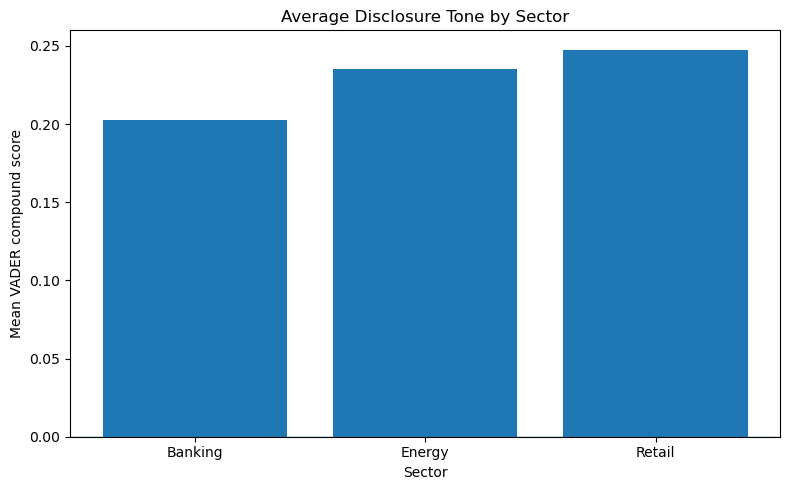

In [67]:
plt.figure(figsize=(8, 5))
plt.bar(
    sector_sentiment.index,
    sector_sentiment["mean_compound"]
)
plt.axhline(0, linewidth=1)
plt.xlabel("Sector")
plt.ylabel("Mean VADER compound score")
plt.title("Average Disclosure Tone by Sector")
plt.tight_layout()
plt.savefig(
    FIGURES_PATH / f"{SOURCE_MODE}_sentiment_by_sector.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# 12. Emerging-risk keyword coverage

The dictionary below is transparent and can be adapted with academic justification.

In [68]:
EMERGING_RISK_DICTIONARY = {
    "cybersecurity": [
        "cyber", "cybersecurity", "data breach", "ransomware",
        "information security", "technology security"
    ],
    "artificial_intelligence": [
        "artificial intelligence", "generative ai", "genai",
        "machine learning", "large language model"
    ],
    "climate_transition": [
        "climate", "net zero", "carbon", "emission",
        "transition risk", "physical risk"
    ],
    "geopolitical": [
        "geopolitical", "sanction", "trade war", "conflict",
        "war", "tariff"
    ],
    "regulatory": [
        "regulatory", "regulation", "compliance",
        "legislation", "regulator"
    ],
    "supply_chain": [
        "supply chain", "supplier", "third party",
        "third-party", "procurement"
    ]
}

coverage_rows = []

for _, row in docs.iterrows():
    normalised = re.sub(r"\s+", " ", row["raw_text"].lower())
    denominator = max(row["raw_word_count"], 1)

    result = {
        "file_name": row["file_name"],
        "company": row["company"],
        "sector": row["sector"],
        "year": row["year"]
    }

    for category, terms in EMERGING_RISK_DICTIONARY.items():
        count = sum(normalised.count(term.lower()) for term in terms)
        result[f"{category}_count"] = count
        result[f"{category}_per_1000_words"] = (count / denominator) * 1000

    coverage_rows.append(result)

risk_coverage = pd.DataFrame(coverage_rows)

risk_coverage.to_csv(
    TABLES_PATH / f"{SOURCE_MODE}_emerging_risk_coverage.csv",
    index=False,
    encoding="utf-8-sig"
)

display(risk_coverage.head())

,file_name,company,sector,year,cybersecurity_count,cybersecurity_per_1000_words,artificial_intelligence_count,artificial_intelligence_per_1000_words,climate_transition_count,climate_transition_per_1000_words,geopolitical_count,geopolitical_per_1000_words,regulatory_count,regulatory_per_1000_words,supply_chain_count,supply_chain_per_1000_words
0,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2023,163,0.504883,5,0.015487,2637,8.167956,719,2.227061,1201,3.720028,233,0.721704
1,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2024,214,0.613775,15,0.043022,2545,7.299333,767,2.199838,1332,3.820319,255,0.731367
2,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2025,242,0.759552,38,0.119268,2009,6.305534,681,2.137416,1432,4.494537,236,0.740720
3,BP ANNUAL REPORTS_bp-annual-report-and-form-20...,BP,Energy,2023,55,0.202377,1,0.003680,1393,5.125658,425,1.563822,432,1.589579,123,0.452589
4,BP ANNUAL REPORTS_bp-annual-report-and-form-20...,BP,Energy,2024,55,0.212977,5,0.019362,1224,4.739704,365,1.413392,393,1.521817,125,0.484038


# 13. Consultancy benchmarking framework

This is a **researcher-designed composite index**, not an established external rating.  
Every component and weight is made explicit so the framework is auditable.

Components:

- **Disclosure detail:** document length
- **Lexical breadth:** vocabulary per 1,000 words
- **Thematic diversity:** entropy of topic distribution
- **Emerging-risk coverage:** dictionary-based emerging risk density
- **Tone balance:** avoids rewarding excessively positive or excessively negative wording

Default weights can be changed and should be justified in Chapter 3.

In [69]:
benchmark = docs[
    [
        "file_name", "company", "sector", "year",
        "raw_word_count", "vocabulary_size"
    ]
].copy()

benchmark["vocabulary_per_1000_words"] = (
    benchmark["vocabulary_size"]
    / benchmark["raw_word_count"].replace(0, np.nan)
    * 1000
)

benchmark = benchmark.merge(
    document_topics[["file_name"] + topic_columns],
    on="file_name",
    how="left"
)

def topic_entropy(row):
    probabilities = row[topic_columns].astype(float).values
    probabilities = probabilities[probabilities > 0]
    entropy = -np.sum(probabilities * np.log(probabilities))
    max_entropy = np.log(len(topic_columns))
    return entropy / max_entropy if max_entropy > 0 else np.nan

benchmark["thematic_diversity"] = benchmark.apply(topic_entropy, axis=1)

coverage_density_columns = [
    column
    for column in risk_coverage.columns
    if column.endswith("_per_1000_words")
]

coverage_total = risk_coverage[["file_name"] + coverage_density_columns].copy()
coverage_total["emerging_risk_coverage"] = coverage_total[
    coverage_density_columns
].sum(axis=1)

benchmark = benchmark.merge(
    coverage_total[["file_name", "emerging_risk_coverage"]],
    on="file_name",
    how="left"
)

benchmark = benchmark.merge(
    sentiment[["file_name", "mean_compound"]],
    on="file_name",
    how="left"
)

benchmark["tone_balance"] = 1 - benchmark["mean_compound"].abs().clip(0, 1)

raw_components = {
    "detail": "raw_word_count",
    "breadth": "vocabulary_per_1000_words",
    "diversity": "thematic_diversity",
    "emerging_risk": "emerging_risk_coverage",
    "tone_balance": "tone_balance"
}

scaler = MinMaxScaler()

for score_name, source_column in raw_components.items():
    benchmark[f"{score_name}_score"] = (
        scaler.fit_transform(benchmark[[source_column]]).ravel() * 100
    )

WEIGHTS = {
    "detail_score": 0.20,
    "breadth_score": 0.20,
    "diversity_score": 0.25,
    "emerging_risk_score": 0.25,
    "tone_balance_score": 0.10
}

benchmark["overall_score"] = sum(
    benchmark[column] * weight
    for column, weight in WEIGHTS.items()
)

benchmark["rank"] = benchmark["overall_score"].rank(
    ascending=False,
    method="min"
).astype(int)

benchmark = benchmark.sort_values(
    ["rank", "company", "year"]
)

benchmark.to_csv(
    TABLES_PATH / f"{SOURCE_MODE}_benchmark_scores_by_report.csv",
    index=False,
    encoding="utf-8-sig"
)

display(
    benchmark[
        [
            "rank", "company", "sector", "year",
            "detail_score", "breadth_score",
            "diversity_score", "emerging_risk_score",
            "tone_balance_score", "overall_score"
        ]
    ]
)

,rank,company,sector,year,detail_score,breadth_score,diversity_score,emerging_risk_score,tone_balance_score,overall_score
0,1,Barclays,Banking,2023,88.275399,16.392884,0.004878,100.000000,98.807459,55.815622
1,2,Barclays,Banking,2024,99.748886,8.194247,0.001369,91.053249,90.908964,53.443177
19,3,Shell,Energy,2024,90.979880,39.858263,0.000000,73.178267,85.996159,53.061811
2,4,Barclays,Banking,2025,86.391819,16.983111,0.004412,88.978290,100.000000,52.920661
20,5,Shell,Energy,2025,91.767001,39.236090,0.001411,73.813543,77.782164,52.432573
24,6,Tesco,Retail,2023,12.008160,80.530245,100.000000,8.307465,36.266772,49.211224
25,7,Tesco,Retail,2024,17.131340,70.964414,95.998250,0.411900,53.440766,47.065765
18,8,Shell,Energy,2023,62.225719,64.909027,0.008560,53.241244,77.013150,46.440715
26,9,Tesco,Retail,2025,12.581946,77.317172,87.779301,3.500085,40.971587,44.896829
21,10,SSE,Energy,2023,39.801420,39.787622,87.452142,16.548705,6.973175,42.615338


## 13.1 Company-level benchmark

The company score is the average across 2023–2025.

In [70]:
company_benchmark = (
    benchmark.groupby(["company", "sector"], as_index=False)
    .agg(
        detail_score=("detail_score", "mean"),
        breadth_score=("breadth_score", "mean"),
        diversity_score=("diversity_score", "mean"),
        emerging_risk_score=("emerging_risk_score", "mean"),
        tone_balance_score=("tone_balance_score", "mean"),
        overall_score=("overall_score", "mean")
    )
    .sort_values("overall_score", ascending=False)
)

company_benchmark["rank"] = (
    company_benchmark["overall_score"]
    .rank(ascending=False, method="min")
    .astype(int)
)

company_benchmark.to_csv(
    TABLES_PATH / f"{SOURCE_MODE}_company_benchmark.csv",
    index=False,
    encoding="utf-8-sig"
)

display(company_benchmark)

,company,sector,detail_score,breadth_score,diversity_score,emerging_risk_score,tone_balance_score,overall_score,rank
1,Barclays,Banking,91.472034,13.856747,0.003553,93.343846,96.572141,54.059820,1
7,Shell,Energy,81.657533,48.001127,0.003324,66.744351,80.263824,50.645033,2
8,Tesco,Retail,13.907148,76.270610,94.592517,4.073150,43.559708,47.057939,3
6,SSE,Energy,34.075121,45.752559,86.195661,16.008564,4.458924,41.962485,4
2,HSBC,Banking,90.827878,5.353755,2.634020,48.798146,88.069522,40.901320,5
4,Marks & Spencer,Retail,3.159153,92.173384,64.274632,0.917009,19.473331,37.311751,6
0,BP,Energy,62.918320,62.661508,8.972365,7.004794,67.326414,35.842897,7
3,Lloyds Banking Group,Banking,48.098123,36.264328,21.425339,8.824193,55.822940,30.017167,8
5,Next,Retail,4.146426,91.634968,0.230975,5.358795,55.547302,26.108452,9


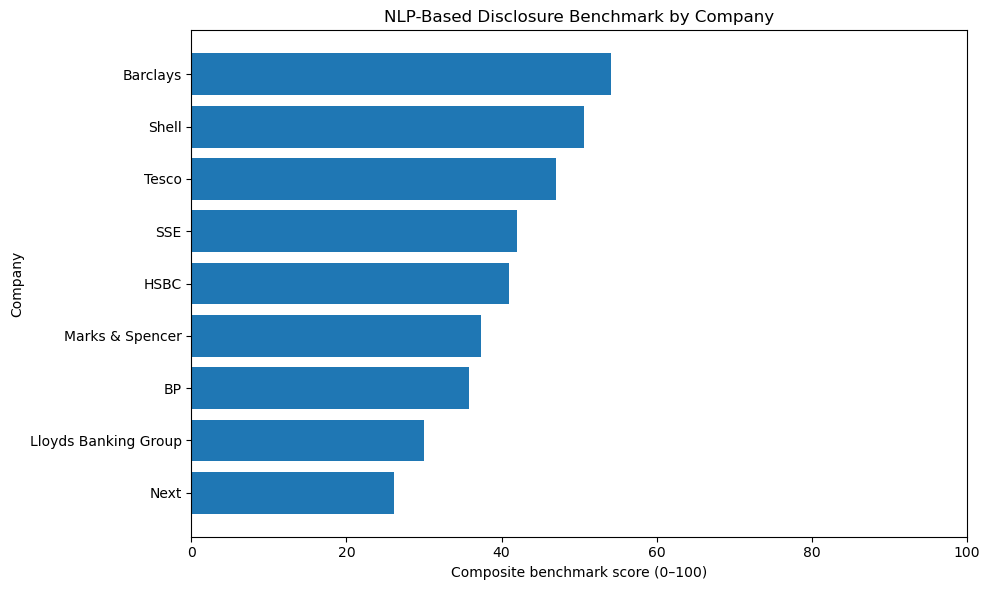

In [71]:
plot_company = company_benchmark.sort_values("overall_score")

plt.figure(figsize=(10, 6))
plt.barh(plot_company["company"], plot_company["overall_score"])
plt.xlabel("Composite benchmark score (0–100)")
plt.ylabel("Company")
plt.title("NLP-Based Disclosure Benchmark by Company")
plt.xlim(0, 100)
plt.tight_layout()
plt.savefig(
    FIGURES_PATH / f"{SOURCE_MODE}_company_benchmark.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# 14. Sensitivity analysis for benchmark weights

A strong dissertation should show that rankings are not entirely dependent on one arbitrary weighting scheme.

In [72]:
ALTERNATIVE_WEIGHTS = {
    "equal_weights": {
        "detail_score": 0.20,
        "breadth_score": 0.20,
        "diversity_score": 0.20,
        "emerging_risk_score": 0.20,
        "tone_balance_score": 0.20
    },
    "investor_focus": {
        "detail_score": 0.15,
        "breadth_score": 0.15,
        "diversity_score": 0.25,
        "emerging_risk_score": 0.35,
        "tone_balance_score": 0.10
    }
}

sensitivity = benchmark[
    ["file_name", "company", "sector", "year"]
].copy()

for scenario, weights in ALTERNATIVE_WEIGHTS.items():
    sensitivity[f"{scenario}_score"] = sum(
        benchmark[column] * weight
        for column, weight in weights.items()
    )
    sensitivity[f"{scenario}_rank"] = (
        sensitivity[f"{scenario}_score"]
        .rank(ascending=False, method="min")
        .astype(int)
    )

sensitivity.to_csv(
    TABLES_PATH / f"{SOURCE_MODE}_benchmark_sensitivity_analysis.csv",
    index=False,
    encoding="utf-8-sig"
)

display(sensitivity.head())

,file_name,company,sector,year,equal_weights_score,equal_weights_rank,investor_focus_score,investor_focus_rank
0,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2023,60.696124,1,60.582208,1
1,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2024,57.981343,4,57.151346,2
19,SHELL ANNUALREPORTS_shell-annual-report-2024.txt,Shell,Energy,2024,58.002514,3,53.837731,4
2,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2025,58.471526,2,56.649744,3
20,SHELL ANNUALREPORTS_shell-annual-report-2025-i...,Shell,Energy,2025,56.520042,5,53.263773,5


# 15. Save models and package information

In [73]:
joblib.dump(
    tfidf_vectorizer,
    MODELS_PATH / f"{SOURCE_MODE}_tfidf_vectorizer.joblib"
)
joblib.dump(
    count_vectorizer,
    MODELS_PATH / f"{SOURCE_MODE}_count_vectorizer.joblib"
)
joblib.dump(
    lda_model,
    MODELS_PATH / f"{SOURCE_MODE}_lda_model.joblib"
)

package_info = pd.DataFrame({
    "component": [
        "Python", "pandas", "numpy", "scikit-learn",
        "nltk", "source_mode", "random_state",
        "documents_loaded"
    ],
    "value": [
        platform.python_version(),
        pd.__version__,
        np.__version__,
        __import__("sklearn").__version__,
        nltk.__version__,
        SOURCE_MODE,
        RANDOM_STATE,
        len(docs)
    ]
})

package_info.to_csv(
    TABLES_PATH / f"{SOURCE_MODE}_reproducibility_information.csv",
    index=False,
    encoding="utf-8-sig"
)

display(package_info)

,component,value
0,Python,3.13.5
1,pandas,2.2.3
2,numpy,2.1.3
3,scikit-learn,1.6.1
4,nltk,3.9.1
5,source_mode,full_reports
6,random_state,42
7,documents_loaded,27


# 16. Readability analysis
Measures: Flesch Reading Ease, Flesch–Kincaid Grade Level, Gunning Fog Index and average sentence length.

In [74]:
def readability_metrics(text: str) -> dict:
    sentences = [s for s in sent_tokenize(text) if len(s.split()) >= 3]
    words = re.findall(r"\b[a-zA-Z]+\b", text)
    avg_sentence_length = len(words) / len(sentences) if sentences else np.nan
    return {
        "flesch_reading_ease": textstat.flesch_reading_ease(text),
        "flesch_kincaid_grade": textstat.flesch_kincaid_grade(text),
        "gunning_fog": textstat.gunning_fog(text),
        "average_sentence_length": avg_sentence_length
    }
readability_results = docs["raw_text"].apply(readability_metrics).apply(pd.Series)
readability = pd.concat([docs[["file_name","company","sector","year"]].reset_index(drop=True), readability_results], axis=1)
readability.to_csv(TABLES_PATH / f"{SOURCE_MODE}_readability_by_report.csv", index=False, encoding="utf-8-sig")
display(readability.sort_values("flesch_reading_ease"))

,file_name,company,sector,year,flesch_reading_ease,flesch_kincaid_grade,gunning_fog,average_sentence_length
0,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2023,23.878338,16.893300,20.472908,32.897499
2,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2025,24.443247,16.658875,20.274571,32.303897
1,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2024,24.778538,16.660552,20.287634,32.392571
11,LLOYDS ANNUAL REPORT_2025-lbg-annual-report.txt,Lloyds Banking Group,Banking,2025,26.162313,16.864191,20.488145,34.298582
10,LLOYDS ANNUAL REPORT_2024-lbg-annual-report.txt,Lloyds Banking Group,Banking,2024,26.463940,17.017180,20.604188,35.288384
20,SHELL ANNUALREPORTS_shell-annual-report-2025-i...,Shell,Energy,2025,26.652235,15.811642,19.473264,26.756581
19,SHELL ANNUALREPORTS_shell-annual-report-2024.txt,Shell,Energy,2024,27.114491,15.637488,19.305176,26.663296
9,LLOYDS ANNUAL REPORT_2023-lbg-annual-report.txt,Lloyds Banking Group,Banking,2023,27.562412,16.751504,20.390788,34.746497
18,SHELL ANNUALREPORTS_shell-annual-report-2023.txt,Shell,Energy,2023,29.078078,15.527291,19.212781,27.979009
26,TESCO ANNUAL REPORTS_tesco_ar25_interactive.txt,Tesco,Retail,2025,29.722076,15.210517,18.927290,27.306664


,flesch_reading_ease,flesch_kincaid_grade,gunning_fog,average_sentence_length
sector,,,,
Banking,27.468283,16.234410,19.829812,32.607219
Energy,31.168850,14.577167,18.297028,27.685802
Retail,36.335273,13.688652,17.190859,27.226043


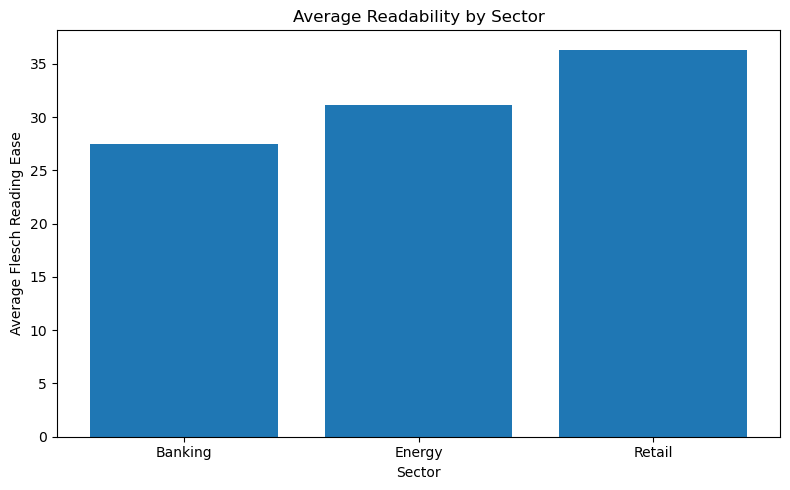

In [75]:
sector_readability = readability.groupby("sector")[["flesch_reading_ease","flesch_kincaid_grade","gunning_fog","average_sentence_length"]].mean()
sector_readability.to_csv(TABLES_PATH / f"{SOURCE_MODE}_readability_by_sector.csv", encoding="utf-8-sig")
display(sector_readability)
plt.figure(figsize=(8,5)); plt.bar(sector_readability.index, sector_readability["flesch_reading_ease"])
plt.xlabel("Sector"); plt.ylabel("Average Flesch Reading Ease"); plt.title("Average Readability by Sector"); plt.tight_layout()
plt.savefig(FIGURES_PATH / f"{SOURCE_MODE}_readability_by_sector.png", dpi=300, bbox_inches="tight"); plt.show()

# 17. Statistical comparisons


## 17.1. Kruskal–Wallis tests compare sectors without assuming normality.

In [76]:
analysis_for_tests = benchmark[["file_name","company","sector","year","overall_score"]].merge(sentiment[["file_name","mean_compound"]], on="file_name", how="left").merge(readability[["file_name","flesch_reading_ease","gunning_fog","average_sentence_length"]], on="file_name", how="left")
TEST_VARIABLES=["overall_score","mean_compound","flesch_reading_ease","gunning_fog","average_sentence_length"]
rows=[]
for variable in TEST_VARIABLES:
    groups=[g[variable].dropna().values for _,g in analysis_for_tests.groupby("sector")]
    if len(groups)>=2 and all(len(x)>0 for x in groups):
        statistic,p_value=stats.kruskal(*groups)
        rows.append({"variable":variable,"test":"Kruskal-Wallis","statistic":statistic,"p_value":p_value,"significant_at_5_percent":p_value<0.05})
sector_tests=pd.DataFrame(rows)
sector_tests.to_csv(TABLES_PATH / f"{SOURCE_MODE}_sector_statistical_tests.csv", index=False, encoding="utf-8-sig")
display(sector_tests)

,variable,test,statistic,p_value,significant_at_5_percent
0,overall_score,Kruskal-Wallis,1.844797,0.397564,False
1,mean_compound,Kruskal-Wallis,10.225750,0.006019,True
2,flesch_reading_ease,Kruskal-Wallis,12.320988,0.002111,True
3,gunning_fog,Kruskal-Wallis,12.285714,0.002149,True
4,average_sentence_length,Kruskal-Wallis,18.000000,0.000123,True


## 17.2. DESCRIPTIVE STATISTICS

In [77]:
# ==========================================================
# DESCRIPTIVE STATISTICS
# ==========================================================

analysis_data = (
    docs[
        [
            "file_name",
            "company",
            "sector",
            "year",
            "lexical_diversity"
        ]
    ]
    .merge(
        sentiment[
            [
                "file_name",
                "mean_compound"
            ]
        ],
        on="file_name",
        how="left"
    )
    .merge(
        readability[
            [
                "file_name",
                "flesch_reading_ease",
                "gunning_fog",
                "average_sentence_length"
            ]
        ],
        on="file_name",
        how="left"
    )
)

analysis_vars = [
    "mean_compound",
    "flesch_reading_ease",
    "gunning_fog",
    "average_sentence_length",
    "lexical_diversity"
]

print("Missing values by variable:")
display(
    analysis_data[analysis_vars]
    .isna()
    .sum()
    .to_frame("missing_values")
)

descriptive_stats = (
    analysis_data
    .groupby("sector")[analysis_vars]
    .agg(["count", "mean", "std", "min", "max"])
    .round(3)
)

display(descriptive_stats)

descriptive_stats.to_csv(
    TABLES_PATH / f"{SOURCE_MODE}_descriptive_statistics.csv",
    encoding="utf-8-sig"
)

Missing values by variable:


,missing_values
mean_compound,0
flesch_reading_ease,0
gunning_fog,0
average_sentence_length,0
lexical_diversity,0


mean_compound                             flesch_reading_ease          \
                count   mean    std    min    max               count    mean   
sector                                                                          
Banking             9  0.202  0.022  0.180  0.242                   9  27.468   
Energy              9  0.235  0.039  0.196  0.292                   9  31.169   
Retail              9  0.248  0.019  0.226  0.278                   9  36.335   

                                ... average_sentence_length                 \
           std     min     max  ...                   count    mean    std   
sector                          ...                                          
Banking  3.091  23.878  31.616  ...                       9  32.607  1.893   
Energy   2.895  26.652  34.488  ...                       9  27.686  0.673   
Retail   4.386  29.722  40.579  ...                       9  27.226  1.108   

                        lexical_diversity                              
            min     max             count   mean    std    min    max  
sector                                                                 
Banking  30.176  35.288                 9  0.053  0.006  0.046  0.062  
Energy   26.663  28.667                 9  0.064  0.005  0.058  0.070  
Retail   25.711  29.217                 9  0.081  0.004  0.074  0.086  

[3 rows x 25 columns]

## 17.3.  Normality Test (Shapiro–Wilk)

In [78]:
from scipy.stats import shapiro

normality_results = []

for variable in analysis_vars:

    for sector in analysis_data["sector"].dropna().unique():

        values = (
            analysis_data.loc[
                analysis_data["sector"] == sector,
                variable
            ]
            .dropna()
        )

        if len(values) >= 3:
            statistic, p = shapiro(values)

            normality_results.append({
                "Variable": variable,
                "Sector": sector,
                "n": len(values),
                "W": statistic,
                "p_value": p,
                "Normal": p > 0.05
            })

normality_df = pd.DataFrame(normality_results)

display(normality_df)

normality_df.to_csv(
    TABLES_PATH / f"{SOURCE_MODE}_normality_tests.csv",
    index=False,
    encoding="utf-8-sig"
)

,Variable,Sector,n,W,p_value,Normal
0,mean_compound,Banking,9,0.890727,0.202989,True
1,mean_compound,Energy,9,0.781813,0.012637,False
2,mean_compound,Retail,9,0.905960,0.288613,True
3,flesch_reading_ease,Banking,9,0.869253,0.120708,True
4,flesch_reading_ease,Energy,9,0.896849,0.234298,True
5,flesch_reading_ease,Retail,9,0.785871,0.014069,False
6,gunning_fog,Banking,9,0.715686,0.002163,False
7,gunning_fog,Energy,9,0.904967,0.282222,True
8,gunning_fog,Retail,9,0.737909,0.003924,False
9,average_sentence_length,Banking,9,0.930130,0.482585,True


## 17.4.  Levene's Test

In [79]:
from scipy.stats import levene

levene_results = []

for variable in analysis_vars:

    banking = (
        analysis_data.loc[
            analysis_data["sector"] == "Banking",
            variable
        ]
        .dropna()
    )

    energy = (
        analysis_data.loc[
            analysis_data["sector"] == "Energy",
            variable
        ]
        .dropna()
    )

    retail = (
        analysis_data.loc[
            analysis_data["sector"] == "Retail",
            variable
        ]
        .dropna()
    )

    stat, p = levene(
        banking,
        energy,
        retail,
        center="median"
    )

    levene_results.append({
        "Variable": variable,
        "Statistic": stat,
        "p_value": p,
        "Equal_Variance": p > 0.05
    })

levene_df = pd.DataFrame(levene_results)

display(levene_df)

levene_df.to_csv(
    TABLES_PATH / f"{SOURCE_MODE}_levene_tests.csv",
    index=False,
    encoding="utf-8-sig"
)

,Variable,Statistic,p_value,Equal_Variance
0,mean_compound,1.232730,0.309301,True
1,flesch_reading_ease,0.333847,0.719436,True
2,gunning_fog,0.304991,0.739945,True
3,average_sentence_length,3.702586,0.039675,False
4,lexical_diversity,0.456798,0.638701,True


## 17.5. ANOVA

In [80]:
from scipy.stats import f_oneway

anova_results = []

for variable in analysis_vars:

    banking = (
        analysis_data.loc[
            analysis_data["sector"] == "Banking",
            variable
        ]
        .dropna()
    )

    energy = (
        analysis_data.loc[
            analysis_data["sector"] == "Energy",
            variable
        ]
        .dropna()
    )

    retail = (
        analysis_data.loc[
            analysis_data["sector"] == "Retail",
            variable
        ]
        .dropna()
    )

    F, p = f_oneway(
        banking,
        energy,
        retail
    )

    anova_results.append({
        "Variable": variable,
        "F": F,
        "p_value": p,
        "Significant": p < 0.05
    })

anova_df = pd.DataFrame(anova_results)

display(anova_df)

anova_df.to_csv(
    TABLES_PATH / f"{SOURCE_MODE}_anova_results.csv",
    index=False,
    encoding="utf-8-sig"
)

,Variable,F,p_value,Significant
0,mean_compound,6.156258,6.947985e-03,True
1,flesch_reading_ease,14.405297,7.760365e-05,True
2,gunning_fog,15.223345,5.381175e-05,True
3,average_sentence_length,45.656433,6.606961e-09,True
4,lexical_diversity,65.885194,1.789436e-10,True


# 18. Correlation analysis
Spearman correlation examines monotonic relationships among disclosure characteristics.

In [81]:
correlation_data = benchmark[["file_name","raw_word_count","vocabulary_per_1000_words","thematic_diversity","emerging_risk_coverage","tone_balance","overall_score"]].merge(sentiment[["file_name","mean_compound"]], on="file_name", how="left").merge(readability[["file_name","flesch_reading_ease","flesch_kincaid_grade","gunning_fog","average_sentence_length"]], on="file_name", how="left")
print("Missing values:", correlation_data.isna().sum().sum())
correlation_matrix=correlation_data.drop(columns=["file_name"]).corr(method="spearman")
correlation_matrix.to_csv(TABLES_PATH / f"{SOURCE_MODE}_spearman_correlation_matrix.csv", encoding="utf-8-sig")
display(correlation_matrix.round(3))

Missing values: 0


,raw_word_count,vocabulary_per_1000_words,thematic_diversity,emerging_risk_coverage,tone_balance,overall_score,mean_compound,flesch_reading_ease,flesch_kincaid_grade,gunning_fog,average_sentence_length
raw_word_count,1.000,-0.886,-0.570,0.802,0.806,0.505,-0.806,-0.687,0.634,0.620,0.468
vocabulary_per_1000_words,-0.886,1.000,0.366,-0.776,-0.632,-0.427,0.632,0.674,-0.657,-0.648,-0.686
thematic_diversity,-0.570,0.366,1.000,-0.600,-0.810,-0.175,0.810,0.347,-0.277,-0.250,0.047
emerging_risk_coverage,0.802,-0.776,-0.600,1.000,0.635,0.623,-0.635,-0.598,0.532,0.518,0.368
tone_balance,0.806,-0.632,-0.810,0.635,1.000,0.350,-1.000,-0.627,0.559,0.538,0.302
overall_score,0.505,-0.427,-0.175,0.623,0.350,1.000,-0.350,-0.539,0.437,0.436,0.154
mean_compound,-0.806,0.632,0.810,-0.635,-1.000,-0.350,1.000,0.627,-0.559,-0.538,-0.302
flesch_reading_ease,-0.687,0.674,0.347,-0.598,-0.627,-0.539,0.627,1.000,-0.971,-0.974,-0.627
flesch_kincaid_grade,0.634,-0.657,-0.277,0.532,0.559,0.437,-0.559,-0.971,1.000,0.996,0.666
gunning_fog,0.620,-0.648,-0.250,0.518,0.538,0.436,-0.538,-0.974,0.996,1.000,0.676


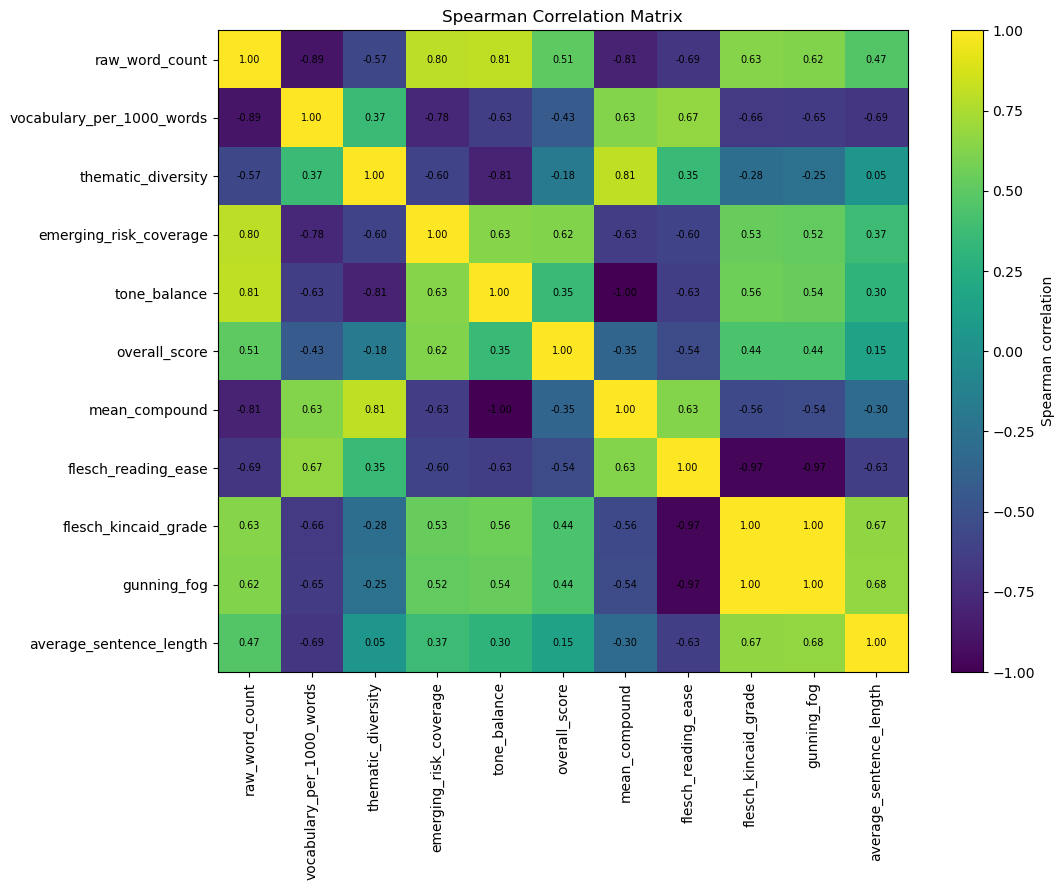

In [82]:
plt.figure(figsize=(11,9)); image=plt.imshow(correlation_matrix.values,vmin=-1,vmax=1,aspect="auto"); plt.colorbar(image,label="Spearman correlation")
plt.xticks(range(len(correlation_matrix.columns)),correlation_matrix.columns,rotation=90); plt.yticks(range(len(correlation_matrix.index)),correlation_matrix.index)
for i in range(correlation_matrix.shape[0]):
    for j in range(correlation_matrix.shape[1]):
        plt.text(j,i,f"{correlation_matrix.iloc[i,j]:.2f}",ha="center",va="center",fontsize=7)
plt.title("Spearman Correlation Matrix"); plt.tight_layout(); plt.savefig(FIGURES_PATH / f"{SOURCE_MODE}_correlation_heatmap.png",dpi=300,bbox_inches="tight"); plt.show()

# 19. Trend analysis, 2023–2025

In [83]:
trend_data=benchmark[["file_name","company","sector","year","overall_score","emerging_risk_coverage","thematic_diversity"]].merge(sentiment[["file_name","mean_compound"]],on="file_name",how="left").merge(readability[["file_name","flesch_reading_ease","gunning_fog"]],on="file_name",how="left")
print("Missing values:", trend_data.isna().sum().sum())
sector_year_trends=trend_data.groupby(["sector","year"],as_index=False).agg(average_benchmark=("overall_score","mean"),average_sentiment=("mean_compound","mean"),average_emerging_risk_coverage=("emerging_risk_coverage","mean"),average_topic_diversity=("thematic_diversity","mean"),average_readability=("flesch_reading_ease","mean"))
sector_year_trends.to_csv(TABLES_PATH / f"{SOURCE_MODE}_sector_year_trends.csv",index=False,encoding="utf-8-sig")
display(sector_year_trends)

Missing values: 0


,sector,year,average_benchmark,average_sentiment,average_emerging_risk_coverage,average_topic_diversity,average_readability
0,Banking,2023,41.592422,0.201159,11.862014,0.039375,27.595890
1,Banking,2024,41.669086,0.204453,11.739095,0.041540,27.619481
2,Banking,2025,41.716799,0.201423,11.651533,0.065035,27.189478
3,Energy,2023,42.080417,0.236342,10.066563,0.195092,31.801062
4,Energy,2024,43.008300,0.230637,10.324246,0.182498,30.912350
5,Energy,2025,43.361698,0.238417,10.418565,0.197588,30.793138
6,Retail,2023,36.763066,0.253851,8.365103,0.337048,36.237776
7,Retail,2024,37.651903,0.242377,8.219957,0.323168,36.793499
8,Retail,2025,36.063173,0.246403,8.459844,0.300839,35.974543


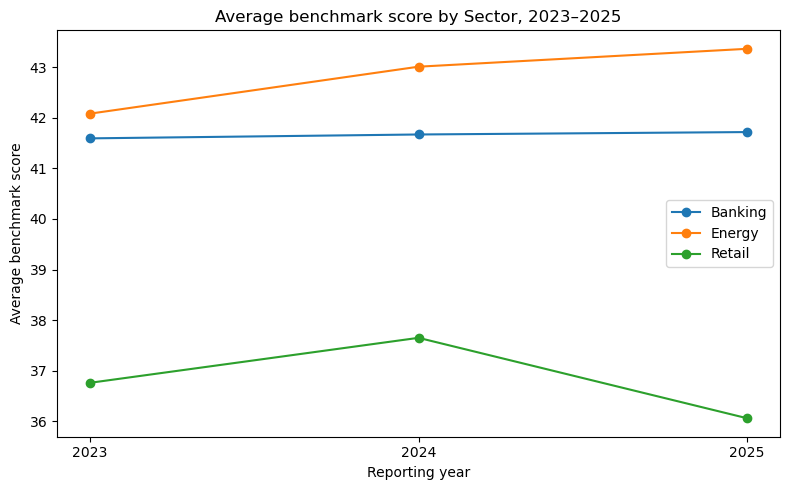

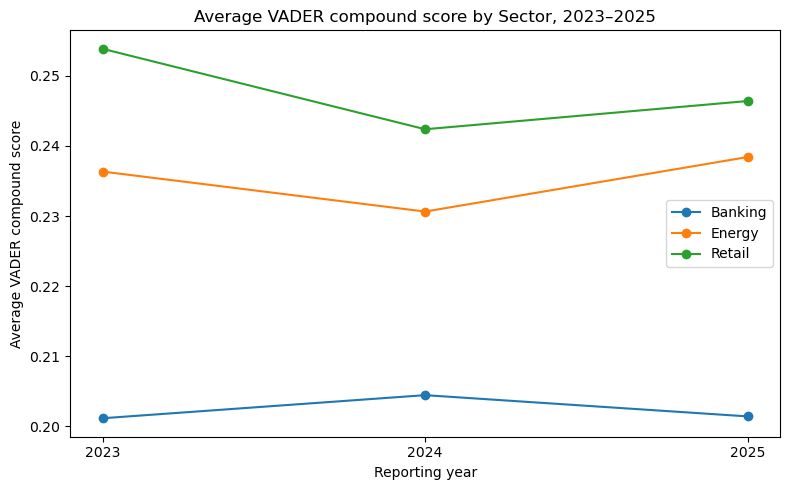

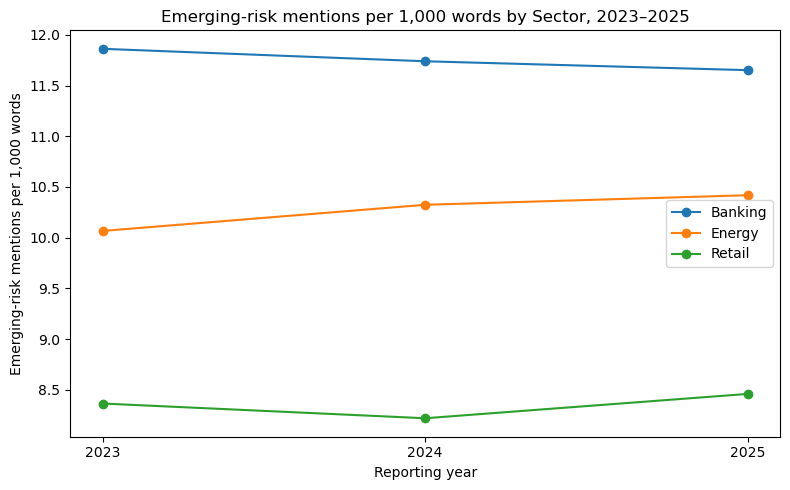

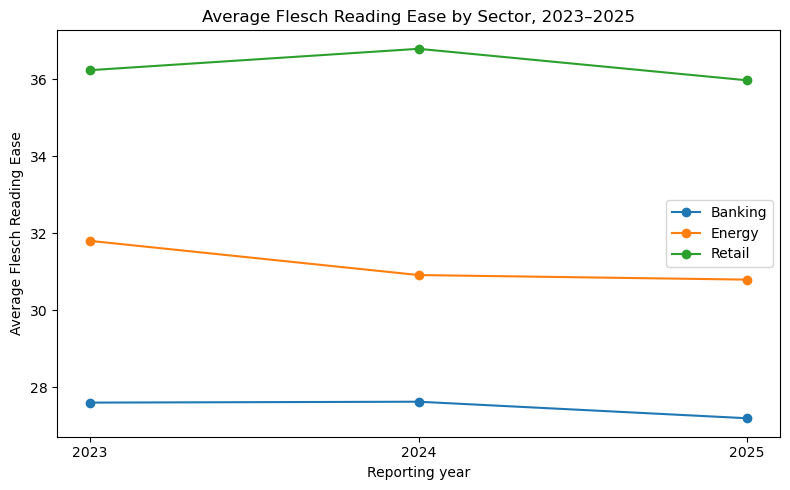

In [84]:
for metric,ylabel,filename in [("average_benchmark","Average benchmark score","benchmark_trend"),("average_sentiment","Average VADER compound score","sentiment_trend"),("average_emerging_risk_coverage","Emerging-risk mentions per 1,000 words","emerging_risk_trend"),("average_readability","Average Flesch Reading Ease","readability_trend")]:
    plt.figure(figsize=(8,5))
    for sector,g in sector_year_trends.groupby("sector"):
        g=g.sort_values("year"); plt.plot(g["year"],g[metric],marker="o",label=sector)
    plt.xlabel("Reporting year"); plt.ylabel(ylabel); plt.title(ylabel+" by Sector, 2023–2025"); plt.xticks(sorted(sector_year_trends["year"].dropna().unique())); plt.legend(); plt.tight_layout(); plt.savefig(FIGURES_PATH / f"{SOURCE_MODE}_{filename}.png",dpi=300,bbox_inches="tight"); plt.show()

# 20. Word clouds
Supplementary visualisations only; quantitative tables remain the primary evidence.

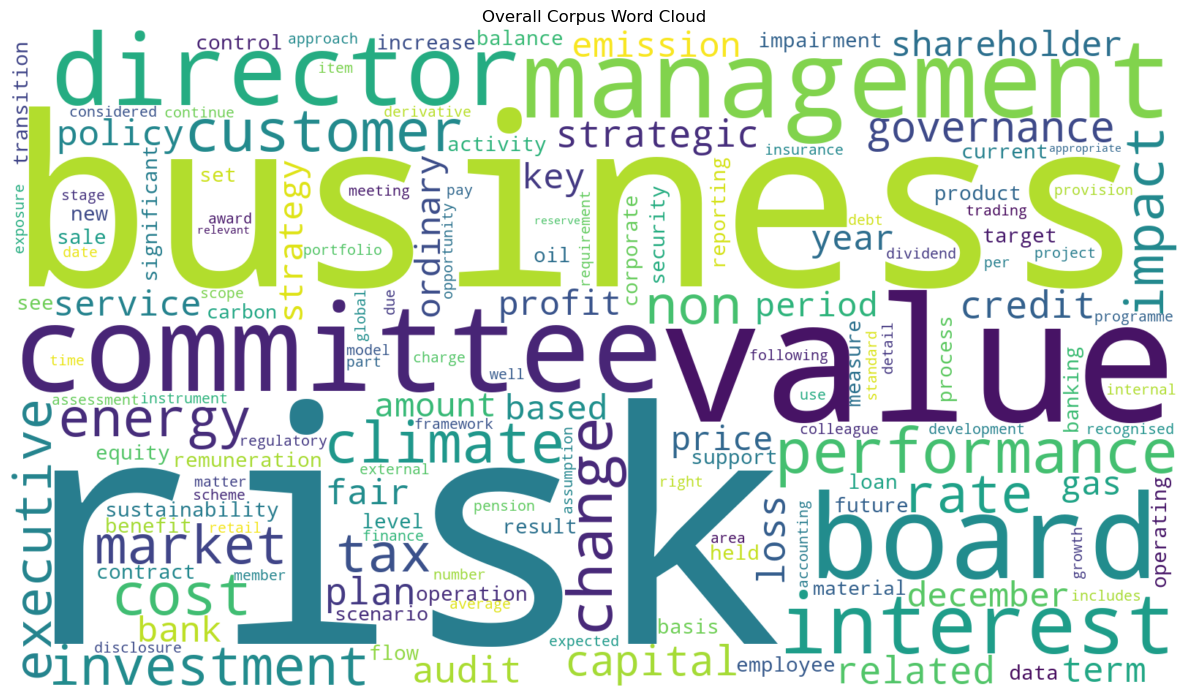

In [85]:
overall_wordcloud=WordCloud(width=1600,height=900,background_color="white",collocations=False,max_words=150).generate(" ".join(docs["clean_text"]))
plt.figure(figsize=(12,7)); plt.imshow(overall_wordcloud,interpolation="bilinear"); plt.axis("off"); plt.title("Overall Corpus Word Cloud"); plt.tight_layout(); plt.savefig(FIGURES_PATH / f"{SOURCE_MODE}_overall_wordcloud.png",dpi=300,bbox_inches="tight"); plt.show()

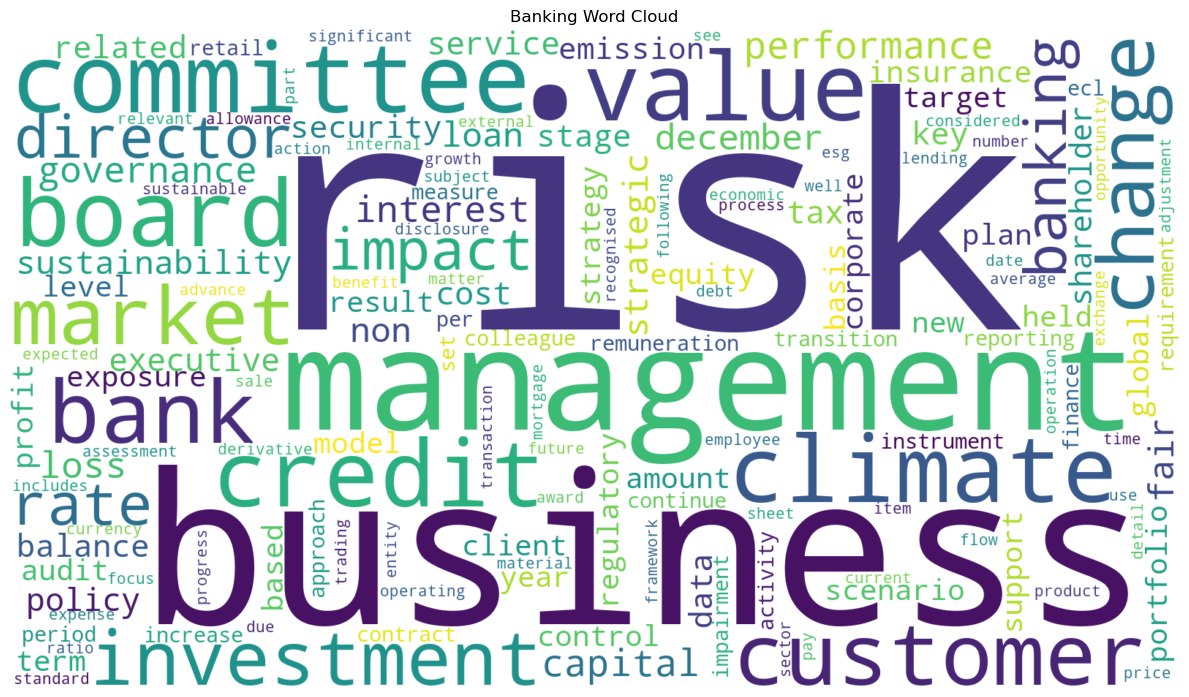

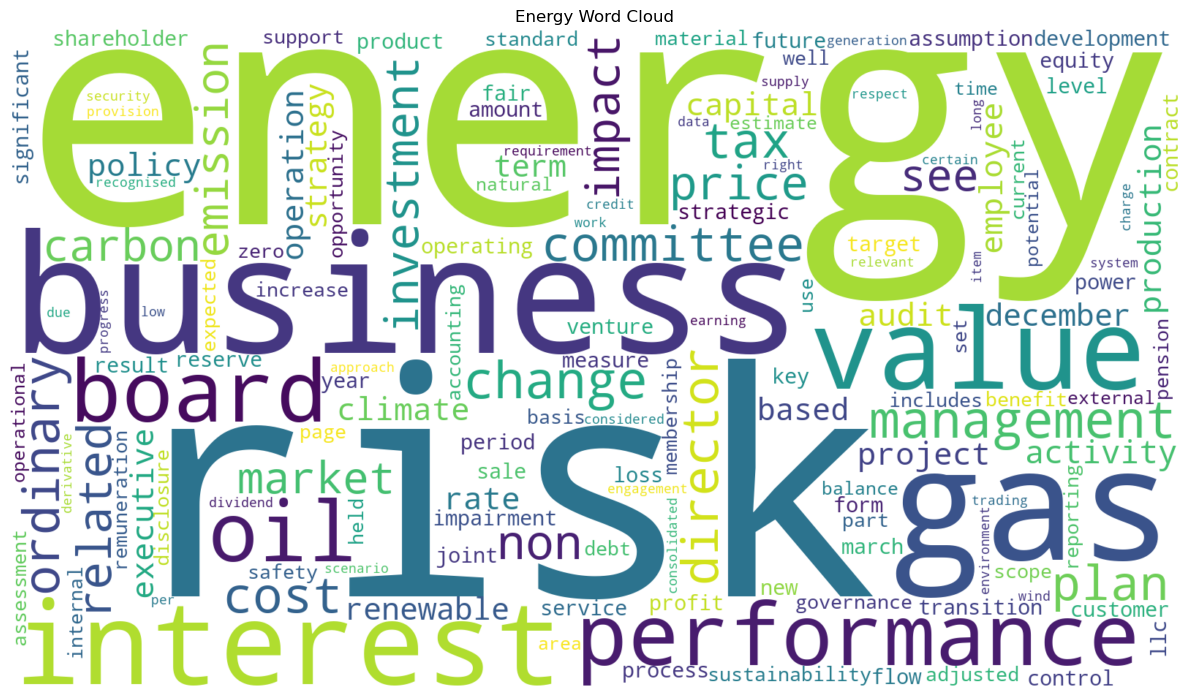

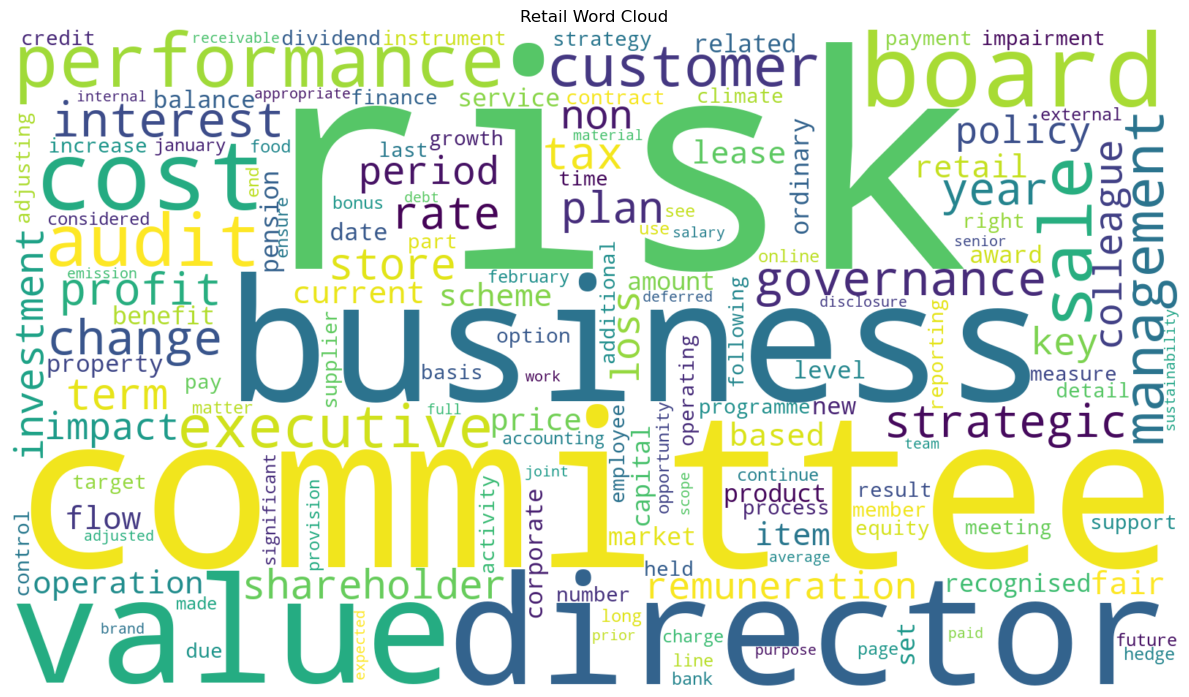

In [86]:
for sector,g in docs.groupby("sector"):
    wc=WordCloud(width=1600,height=900,background_color="white",collocations=False,max_words=150).generate(" ".join(g["clean_text"]))
    plt.figure(figsize=(12,7)); plt.imshow(wc,interpolation="bilinear"); plt.axis("off"); plt.title(f"{sector} Word Cloud"); plt.tight_layout(); safe=sector.lower().replace(" ","_"); plt.savefig(FIGURES_PATH / f"{SOURCE_MODE}_{safe}_wordcloud.png",dpi=300,bbox_inches="tight"); plt.show()

# 21. Enhanced Risk Disclosure Quality Index (RDQI)
Researcher-designed transparent composite index: detail 15%, breadth 15%, thematic diversity 20%, emerging-risk coverage 25%, tone balance 10%, readability 15%.

In [87]:
enhanced_benchmark=benchmark.merge(readability[["file_name","flesch_reading_ease","gunning_fog"]],on="file_name",how="left")
print(
    "Missing values in RDQI inputs:",
    enhanced_benchmark[
        [
            "detail_score",
            "breadth_score",
            "diversity_score",
            "emerging_risk_score",
            "tone_balance_score"
        ]
    ].isna().sum().sum()
)
enhanced_benchmark["readability_score"]=MinMaxScaler().fit_transform(enhanced_benchmark[["flesch_reading_ease"]]).ravel()*100
ENHANCED_WEIGHTS={"detail_score":0.15,"breadth_score":0.15,"diversity_score":0.20,"emerging_risk_score":0.25,"tone_balance_score":0.10,"readability_score":0.15}
enhanced_benchmark["rdqi_score"]=sum(enhanced_benchmark[c]*w for c,w in ENHANCED_WEIGHTS.items())
enhanced_benchmark["rdqi_rank"]=enhanced_benchmark["rdqi_score"].rank(ascending=False,method="min").astype(int)
enhanced_benchmark=enhanced_benchmark.sort_values(["rdqi_rank","company","year"])
enhanced_benchmark.to_csv(TABLES_PATH / f"{SOURCE_MODE}_enhanced_rdqi_by_report.csv",index=False,encoding="utf-8-sig")
display(enhanced_benchmark[["rdqi_rank","company","sector","year","detail_score","breadth_score","diversity_score","emerging_risk_score","tone_balance_score","readability_score","rdqi_score"]])

Missing values in RDQI inputs: 0


,rdqi_rank,company,sector,year,detail_score,breadth_score,diversity_score,emerging_risk_score,tone_balance_score,readability_score,rdqi_score
0,1,Barclays,Banking,2023,88.275399,16.392884,0.004878,100.000000,98.807459,0.000000,50.581964
2,2,Shell,Energy,2024,90.979880,39.858263,0.000000,73.178267,85.996159,19.377023,49.426457
1,3,Barclays,Banking,2024,99.748886,8.194247,0.001369,91.053249,90.908964,5.390102,48.854468
4,4,Shell,Energy,2025,91.767001,39.236090,0.001411,73.813543,77.782164,16.609187,48.373726
3,5,Barclays,Banking,2025,86.391819,16.983111,0.004412,88.978290,100.000000,3.382493,48.259068
5,6,Tesco,Retail,2023,12.008160,80.530245,100.000000,8.307465,36.266772,46.210448,46.515871
7,7,Shell,Energy,2023,62.225719,64.909027,0.008560,53.241244,77.013150,31.134341,44.753701
15,8,Marks & Spencer,Retail,2024,0.000000,100.000000,64.380968,0.000000,24.238782,92.261301,44.139267
6,9,Tesco,Retail,2024,17.131340,70.964414,95.998250,0.411900,53.440766,39.733953,43.821158
11,10,HSBC,Banking,2024,100.000000,0.000000,2.098865,51.279619,84.550723,46.330371,43.644306


In [88]:
company_rdqi=enhanced_benchmark.groupby(["company","sector"],as_index=False).agg(detail_score=("detail_score","mean"),breadth_score=("breadth_score","mean"),diversity_score=("diversity_score","mean"),emerging_risk_score=("emerging_risk_score","mean"),tone_balance_score=("tone_balance_score","mean"),readability_score=("readability_score","mean"),rdqi_score=("rdqi_score","mean")).sort_values("rdqi_score",ascending=False)
company_rdqi["rdqi_rank"]=company_rdqi["rdqi_score"].rank(ascending=False,method="min").astype(int)
company_rdqi.to_csv(TABLES_PATH / f"{SOURCE_MODE}_company_rdqi.csv",index=False,encoding="utf-8-sig")
display(company_rdqi)

,company,sector,detail_score,breadth_score,diversity_score,emerging_risk_score,tone_balance_score,readability_score,rdqi_score,rdqi_rank
1,Barclays,Banking,91.472034,13.856747,0.003553,93.343846,96.572141,2.924198,49.231833,1
7,Shell,Energy,81.657533,48.001127,0.003324,66.744351,80.263824,22.373517,47.517962,2
8,Tesco,Retail,13.907148,76.270610,94.592517,4.073150,43.559708,40.311597,43.866165,3
6,SSE,Energy,34.075121,45.752559,86.195661,16.008564,4.458924,59.943189,42.652796,4
2,HSBC,Banking,90.827878,5.353755,2.634020,48.798146,88.069522,44.489891,42.634021,5
4,Marks & Spencer,Retail,3.159153,92.173384,64.274632,0.917009,19.473331,88.152555,42.554276,6
0,BP,Energy,62.918320,62.661508,8.972365,7.004794,67.326414,48.642883,36.411720,7
5,Next,Retail,4.146426,91.634968,0.230975,5.358795,55.547302,95.299977,35.602830,8
3,Lloyds Banking Group,Banking,48.098123,36.264328,21.425339,8.824193,55.822940,17.072154,27.288601,9


# 22. Executive consultancy dashboard

In [89]:
executive_dashboard=enhanced_benchmark[["file_name","company","sector","year","rdqi_score","rdqi_rank","emerging_risk_coverage","thematic_diversity","readability_score"]].merge(sentiment[["file_name","mean_compound","positive_share","neutral_share","negative_share"]],on="file_name",how="left").merge(document_topics[["file_name","dominant_topic"]],on="file_name",how="left")
print(
    "Missing values in executive dashboard:",
    executive_dashboard.isna().sum().sum()
)
executive_dashboard.to_csv(TABLES_PATH / f"{SOURCE_MODE}_executive_dashboard.csv",index=False,encoding="utf-8-sig")
display(executive_dashboard.sort_values(["rdqi_rank","company","year"]))

Missing values in executive dashboard: 0


,file_name,company,sector,year,rdqi_score,rdqi_rank,emerging_risk_coverage,thematic_diversity,readability_score,mean_compound,positive_share,neutral_share,negative_share,dominant_topic
0,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2023,50.581964,1,15.357120,0.000263,0.000000,0.181594,0.536176,0.243727,0.220097,topic_6
1,SHELL ANNUALREPORTS_shell-annual-report-2024.txt,Shell,Energy,2024,49.426457,2,13.410067,0.000233,19.377023,0.195846,0.525707,0.318538,0.155755,topic_4
2,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2024,48.854468,3,14.707654,0.000242,5.390102,0.190381,0.538454,0.247400,0.214146,topic_6
3,SHELL ANNUALREPORTS_shell-annual-report-2025-i...,Shell,Energy,2025,48.373726,4,13.456183,0.000242,16.609187,0.204984,0.537938,0.305923,0.156138,topic_4
4,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2025,48.259068,5,14.557028,0.000260,3.382493,0.180267,0.532632,0.236399,0.230969,topic_6
5,TESCO ANNUAL REPORTS_tesco 2023.txt,Tesco,Retail,2023,46.515871,6,8.700942,0.603857,46.210448,0.251170,0.576823,0.270616,0.152561,topic_3
6,SHELL ANNUALREPORTS_shell-annual-report-2023.txt,Shell,Energy,2023,44.753701,7,11.962791,0.000285,31.134341,0.205840,0.535975,0.305732,0.158292,topic_4
7,MARKS & SPENCER ANNUAL REPORTS_M-and-S-2024-An...,Marks & Spencer,Retail,2024,44.139267,8,8.097883,0.388852,92.261301,0.264551,0.578834,0.290857,0.130310,topic_2
8,TESCO ANNUAL REPORTS_tesco 2024.txt,Tesco,Retail,2024,43.821158,9,8.127784,0.579701,39.733953,0.232064,0.540890,0.310574,0.148536,topic_3
9,HSBC ANNUAL REPORT_250219-annual-report-and-ac...,HSBC,Banking,2024,43.644306,10,11.820392,0.012903,46.330371,0.197454,0.547049,0.251528,0.201423,topic_5


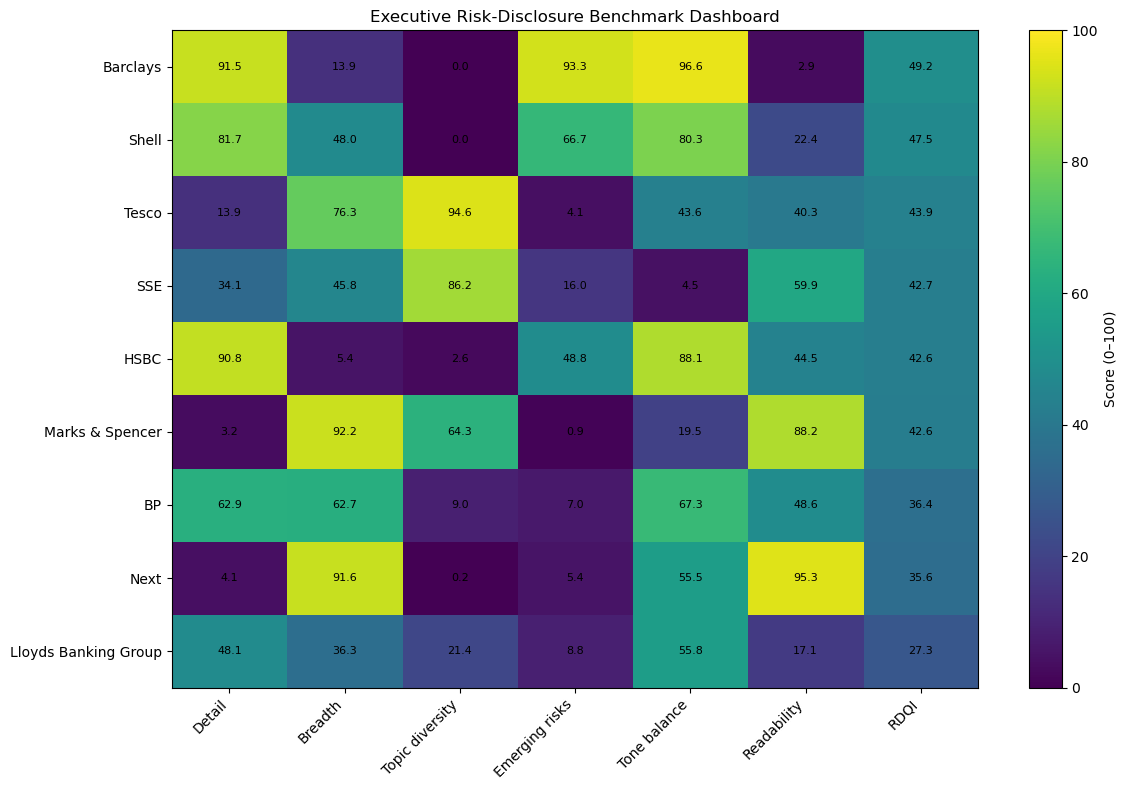

In [90]:
dashboard_matrix=company_rdqi.set_index("company")[["detail_score","breadth_score","diversity_score","emerging_risk_score","tone_balance_score","readability_score","rdqi_score"]]
plt.figure(figsize=(12,8)); image=plt.imshow(dashboard_matrix.values,vmin=0,vmax=100,aspect="auto"); plt.colorbar(image,label="Score (0–100)")
plt.xticks(range(len(dashboard_matrix.columns)),["Detail","Breadth","Topic diversity","Emerging risks","Tone balance","Readability","RDQI"],rotation=45,ha="right"); plt.yticks(range(len(dashboard_matrix.index)),dashboard_matrix.index)
for i in range(dashboard_matrix.shape[0]):
    for j in range(dashboard_matrix.shape[1]): plt.text(j,i,f"{dashboard_matrix.iloc[i,j]:.1f}",ha="center",va="center",fontsize=8)
plt.title("Executive Risk-Disclosure Benchmark Dashboard"); plt.tight_layout(); plt.savefig(FIGURES_PATH / f"{SOURCE_MODE}_executive_dashboard.png",dpi=300,bbox_inches="tight"); plt.show()

# 23. Enhanced RDQI sensitivity analysis

In [91]:
RDQI_SCENARIOS={"balanced":ENHANCED_WEIGHTS,"equal_weights":{"detail_score":1/6,"breadth_score":1/6,"diversity_score":1/6,"emerging_risk_score":1/6,"tone_balance_score":1/6,"readability_score":1/6},"investor_focus":{"detail_score":0.10,"breadth_score":0.10,"diversity_score":0.20,"emerging_risk_score":0.35,"tone_balance_score":0.10,"readability_score":0.15}}
rdqi_sensitivity=enhanced_benchmark[["file_name","company","sector","year"]].copy()
for scenario,weights in RDQI_SCENARIOS.items():
    rdqi_sensitivity[f"{scenario}_score"]=sum(enhanced_benchmark[c]*w for c,w in weights.items())
    rdqi_sensitivity[f"{scenario}_rank"]=rdqi_sensitivity[f"{scenario}_score"].rank(ascending=False,method="min").astype(int)
print(
    "Missing values in sensitivity analysis:",
    rdqi_sensitivity.isna().sum().sum()
)

rdqi_sensitivity.to_csv(TABLES_PATH / f"{SOURCE_MODE}_enhanced_rdqi_sensitivity.csv",index=False,encoding="utf-8-sig")
display(rdqi_sensitivity.head(15))

Missing values in sensitivity analysis: 0


,file_name,company,sector,year,balanced_score,balanced_rank,equal_weights_score,equal_weights_rank,investor_focus_score,investor_focus_rank
0,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2023,50.581964,1,50.580103,2,55.348550,1
2,SHELL ANNUALREPORTS_shell-annual-report-2024.txt,Shell,Energy,2024,49.426457,2,51.564932,1,50.202377,4
1,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2024,48.854468,3,49.216136,5,52.562636,2
4,SHELL ANNUALREPORTS_shell-annual-report-2025-i...,Shell,Energy,2025,48.373726,4,49.868233,3,49.204926,5
3,BARCLAYS ANNUAL REPORT_Barclays-PLC-Annual-Rep...,Barclays,Banking,2025,48.259068,5,49.290021,4,51.988151,3
5,TESCO ANNUAL REPORTS_tesco 2023.txt,Tesco,Retail,2023,46.515871,6,47.220515,8,42.719698,9
7,SHELL ANNUALREPORTS_shell-annual-report-2023.txt,Shell,Energy,2023,44.753701,7,48.088674,6,43.721088,7
15,MARKS & SPENCER ANNUAL REPORTS_M-and-S-2024-An...,Marks & Spencer,Retail,2024,44.139267,8,46.813509,9,39.139267,14
6,TESCO ANNUAL REPORTS_tesco 2024.txt,Tesco,Retail,2024,43.821158,9,46.280104,11,39.457560,13
11,HSBC ANNUAL REPORT_250219-annual-report-and-ac...,HSBC,Banking,2024,43.644306,10,47.376597,7,43.772268,6


# 24. Final output checklist

In [92]:

from pathlib import Path
import pandas as pd


expected_outputs = [


    TABLES_PATH / f"{SOURCE_MODE}_cleaning_summary.csv",
    TABLES_PATH / f"{SOURCE_MODE}_top_30_keywords.csv",
    TABLES_PATH / f"{SOURCE_MODE}_top_tfidf_terms_by_report.csv",
    TABLES_PATH / f"{SOURCE_MODE}_lda_topic_terms.csv",
    TABLES_PATH / f"{SOURCE_MODE}_document_topic_distribution.csv",

    TABLES_PATH / f"{SOURCE_MODE}_sentiment_by_report.csv",
    TABLES_PATH / f"{SOURCE_MODE}_sentiment_by_sector.csv",

    TABLES_PATH / f"{SOURCE_MODE}_readability_by_report.csv",
    TABLES_PATH / f"{SOURCE_MODE}_readability_by_sector.csv",

    TABLES_PATH / f"{SOURCE_MODE}_descriptive_statistics.csv",
    TABLES_PATH / f"{SOURCE_MODE}_normality_tests.csv",
    TABLES_PATH / f"{SOURCE_MODE}_levene_tests.csv",
    TABLES_PATH / f"{SOURCE_MODE}_anova_results.csv",
    TABLES_PATH / f"{SOURCE_MODE}_sector_statistical_tests.csv",

    TABLES_PATH / f"{SOURCE_MODE}_spearman_correlation_matrix.csv",
    TABLES_PATH / f"{SOURCE_MODE}_sector_year_trends.csv",

    TABLES_PATH / f"{SOURCE_MODE}_enhanced_rdqi_by_report.csv",
    TABLES_PATH / f"{SOURCE_MODE}_company_rdqi.csv",
    TABLES_PATH / f"{SOURCE_MODE}_enhanced_rdqi_sensitivity.csv",

  
    TABLES_PATH / f"{SOURCE_MODE}_rdqi_rank_stability.csv",

    TABLES_PATH / f"{SOURCE_MODE}_executive_dashboard.csv",

    
    FIGURES_PATH / f"{SOURCE_MODE}_top_30_keywords.png",
    FIGURES_PATH / f"{SOURCE_MODE}_tfidf_heatmap.png",
    FIGURES_PATH / f"{SOURCE_MODE}_topic_prevalence_by_sector.png",
    FIGURES_PATH / f"{SOURCE_MODE}_sentiment_by_sector.png",
    FIGURES_PATH / f"{SOURCE_MODE}_readability_by_sector.png",
    FIGURES_PATH / f"{SOURCE_MODE}_correlation_heatmap.png",

    FIGURES_PATH / f"{SOURCE_MODE}_benchmark_trend.png",
    FIGURES_PATH / f"{SOURCE_MODE}_sentiment_trend.png",
    FIGURES_PATH / f"{SOURCE_MODE}_emerging_risk_trend.png",
    FIGURES_PATH / f"{SOURCE_MODE}_readability_trend.png",

    FIGURES_PATH / f"{SOURCE_MODE}_executive_dashboard.png",

   
    FIGURES_PATH / f"{SOURCE_MODE}_rdqi_rank_stability.png",
]



checklist = pd.DataFrame({
    "Output": [p.name for p in expected_outputs],
    "Exists": [p.exists() for p in expected_outputs]
})

display(checklist)



created = checklist["Exists"].sum()
total = len(checklist)

print("="*60)
print("FINAL OUTPUT CHECKLIST")
print("="*60)

print(f"Outputs created: {created} / {total}")

missing = checklist.loc[~checklist["Exists"], "Output"]

if len(missing) == 0:
    print("\n All expected outputs were created successfully.")
else:
    print("\n Missing outputs:")
    for file in missing:
        print("-", file)

print("\nTables folder :", TABLES_PATH)
print("Figures folder:", FIGURES_PATH)

print("\nNotebook completed successfully.")

,Output,Exists
0,full_reports_cleaning_summary.csv,True
1,full_reports_top_30_keywords.csv,True
2,full_reports_top_tfidf_terms_by_report.csv,True
3,full_reports_lda_topic_terms.csv,True
4,full_reports_document_topic_distribution.csv,True
5,full_reports_sentiment_by_report.csv,True
6,full_reports_sentiment_by_sector.csv,True
7,full_reports_readability_by_report.csv,True
8,full_reports_readability_by_sector.csv,True
9,full_reports_descriptive_statistics.csv,True


FINAL OUTPUT CHECKLIST
Outputs created: 33 / 33

 All expected outputs were created successfully.

Tables folder : C:\Users\HP\OneDrive\Desktop\Dissertation_project\output\tables
Figures folder: C:\Users\HP\OneDrive\Desktop\Dissertation_project\output\figures

Notebook completed successfully.
